
# Clean notebook: real-image frame candidate search for corridor animation

This notebook searches for **candidate nuclei** that can later be assembled into a corridor-migration animation, using the **native background + DAPI alignment already present in the dataset**.

## What this notebook does
- loads the metadata CSV
- parses `pseudotime`, `pseudotime_widths`, and `pseudotime_center_bin`
- converts each object into a **full ordered width profile** across one corridor period
- builds **20 frame templates**
- scores every object against every frame
- previews candidates using the **real background + DAPI overlay**
- exports grouped candidate folders, metadata CSVs, and contact sheets

## Important design choice
This notebook does **not** synthesize a new corridor projection.  
It uses the **real registered images** from `path_background` and `path_dapi`, which avoids the misalignment problem.

## Expected inputs
The CSV should contain at least:
- `path_background`
- `path_dapi`
- `pseudotime`
- `pseudotime_widths`
- `pseudotime_center_bin`

Optional but useful:
- `dapi_ImageNumber`
- `ObjectNumber`

## Output
A folder structure like:

```text
frame_candidate_search_output/
  f01_entry_10/
    metadata.csv
    candidate_0001_img....png
    candidate_0002_img....png
    contact_sheet_001.png
  ...
  summary_counts.csv
  summary_best_candidates.csv
```


In [1]:

from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile

from IPython.display import display


# ----------------------------
# USER CONFIG
# ----------------------------
CSV_PATH = Path("C:\\Users\\20212358\\OneDrive - TU Eindhoven\\pseudotime_GitHUB\\copy_pseudotime_highres_confinement_scan\\datasets\\Figure_12_GIF\\combined_clustered_data_1462_k5.csv")
OUT_DIR = Path("1462_frame_candidate_search_output_020426")

BG_COL = "path_background"
DAPI_COL = "path_dapi"

PT_BINS_COL = "pseudotime"
PT_WIDTHS_COL = "pseudotime_widths"
PT_CENTER_COL = "pseudotime_center_bin"

IMAGE_NUM_COL = "dapi_ImageNumber"
OBJECT_NUM_COL = "ObjectNumber"

N_PROFILE = 100          # resampled profile length used for scoring
TOP_K_PER_FRAME = 50     # set to None to export all candidates
ROWS_PER_CONTACT_SHEET = 10

# display settings for overlays
BF_WEIGHT = 0.35
DAPI_GAIN = 4.0
DAPI_FIXED_MAX = 160.0
INVERT_BF = True

# crop settings for candidate previews
CROP_THR = 0.15
CROP_PAD = 25

# score weights
W_EMD = 0.50
W_COM = 0.30
W_L2 = 0.20
assert abs((W_EMD + W_COM + W_L2) - 1.0) < 1e-9


In [2]:

# ----------------------------
# PARSING + BASIC HELPERS
# ----------------------------
def parse_vec(x, dtype=float):
    if isinstance(x, np.ndarray):
        return x.astype(dtype)
    if isinstance(x, list):
        return np.asarray(x, dtype=dtype)
    if pd.isna(x):
        return np.array([], dtype=dtype)

    s = str(x).replace("[", " ").replace("]", " ").replace(",", " ").strip()
    if not s:
        return np.array([], dtype=dtype)

    parts = [p for p in s.split() if p]
    return np.asarray(parts, dtype=dtype)


def build_unique_key(row):
    img_num = row.get(IMAGE_NUM_COL, np.nan)
    obj_num = row.get(OBJECT_NUM_COL, np.nan)

    if pd.notna(img_num) and pd.notna(obj_num):
        return f"img{int(img_num):05d}_obj{int(obj_num):05d}"

    stem = Path(str(row.get(DAPI_COL, "missing_dapi"))).stem
    if pd.notna(obj_num):
        return f"{stem}_obj{int(obj_num):05d}"
    return stem


def resolve_existing_path(path_str):
    p = Path(path_str)
    if p.exists():
        return p

    # fallback: same filename in current working directory
    p2 = Path(p.name)
    if p2.exists():
        return p2

    return p


def read_image(path):
    return tifffile.imread(str(resolve_existing_path(path)))


def to_2d(img):
    img = np.asarray(img)
    if img.ndim == 2:
        return img
    if img.ndim == 3:
        if img.shape[0] == 1:
            return img[0]
        if img.shape[-1] == 1:
            return img[..., 0]
        return img[0] if img.shape[0] <= 4 else img[..., 0]
    raise ValueError(f"Unsupported image shape: {img.shape}")


def normalize_percentile(img, pmin=1, pmax=99):
    img = np.asarray(img, dtype=np.float32)
    lo = np.percentile(img, pmin)
    hi = np.percentile(img, pmax)
    if hi <= lo:
        return np.zeros_like(img, dtype=np.float32)
    return np.clip((img - lo) / (hi - lo), 0, 1)


def scale_dapi_fixed(dapi, fixed_max=160.0):
    dapi = np.asarray(dapi, dtype=np.float32)
    if fixed_max <= 0:
        raise ValueError("fixed_max must be > 0")
    return np.clip(dapi / fixed_max, 0, 1)


def make_overlay_fixed_dapi(
    bg,
    dapi,
    bf_weight=0.35,
    dapi_gain=4.0,
    invert_bf=True,
    dapi_fixed_max=160.0
):
    bg_norm = normalize_percentile(bg, 1, 99)

    if invert_bf:
        bg_norm = 1.0 - bg_norm

    dapi_disp = scale_dapi_fixed(dapi, fixed_max=dapi_fixed_max)
    dapi_enh = np.clip(dapi_disp * dapi_gain, 0, 1)

    rgb = np.zeros((*bg.shape, 3), dtype=np.float32)
    rgb[..., 0] = bg_norm * bf_weight
    rgb[..., 1] = bg_norm * bf_weight
    rgb[..., 2] = bg_norm * bf_weight

    rgb[..., 2] += dapi_enh
    rgb[..., 1] += dapi_enh * 0.15
    rgb[..., 0] += dapi_enh * 0.05
    rgb = np.clip(rgb, 0, 1)

    return rgb, dapi_disp, dapi_enh


def crop_from_signal(img, signal, thr=0.15, pad=25):
    mask = signal > thr
    ys, xs = np.where(mask)

    if len(xs) == 0:
        return img

    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, img.shape[0])
    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, img.shape[1])

    return img[y0:y1, x0:x1]


def linearize_profile(pt_bins, pt_widths, period_len):
    '''
    Build a full left-to-right profile with one slot per pseudotime bin.
    Missing bins are filled with zero.
    '''
    v = np.zeros(period_len, dtype=float)

    pt_bins = np.asarray(pt_bins, dtype=int)
    pt_widths = np.asarray(pt_widths, dtype=float)

    if len(pt_bins) == 0 or len(pt_widths) == 0 or len(pt_bins) != len(pt_widths):
        return v

    for b, w in zip(pt_bins, pt_widths):
        if 0 <= int(b) < period_len:
            v[int(b)] = float(w)

    return v


def centered_profile(linear_profile, center_bin):
    '''
    Rotate a full profile so that center_bin sits in the middle.
    Used for diagnostic plotting only.
    '''
    v = np.asarray(linear_profile, dtype=float)
    if len(v) == 0:
        return v

    center_bin = int(center_bin) if pd.notna(center_bin) else 0
    shift = len(v) // 2 - center_bin
    return np.roll(v, shift)


def resample_profile(v, n=100):
    v = np.asarray(v, dtype=float)
    if len(v) == 0:
        return np.zeros(n, dtype=float)
    if len(v) == 1:
        return np.repeat(v[0], n).astype(float)

    x_old = np.linspace(0, 1, len(v))
    x_new = np.linspace(0, 1, n)
    return np.interp(x_new, x_old, v)


def normalize_profile(v):
    v = np.asarray(v, dtype=float)
    v = np.clip(v, 0, None)
    s = v.sum()
    if s <= 0:
        return np.zeros_like(v, dtype=float)
    return v / s


def profile_center_of_mass(v):
    p = normalize_profile(v)
    if p.sum() <= 0:
        return np.nan
    x = np.linspace(0, 1, len(p))
    return float((x * p).sum())


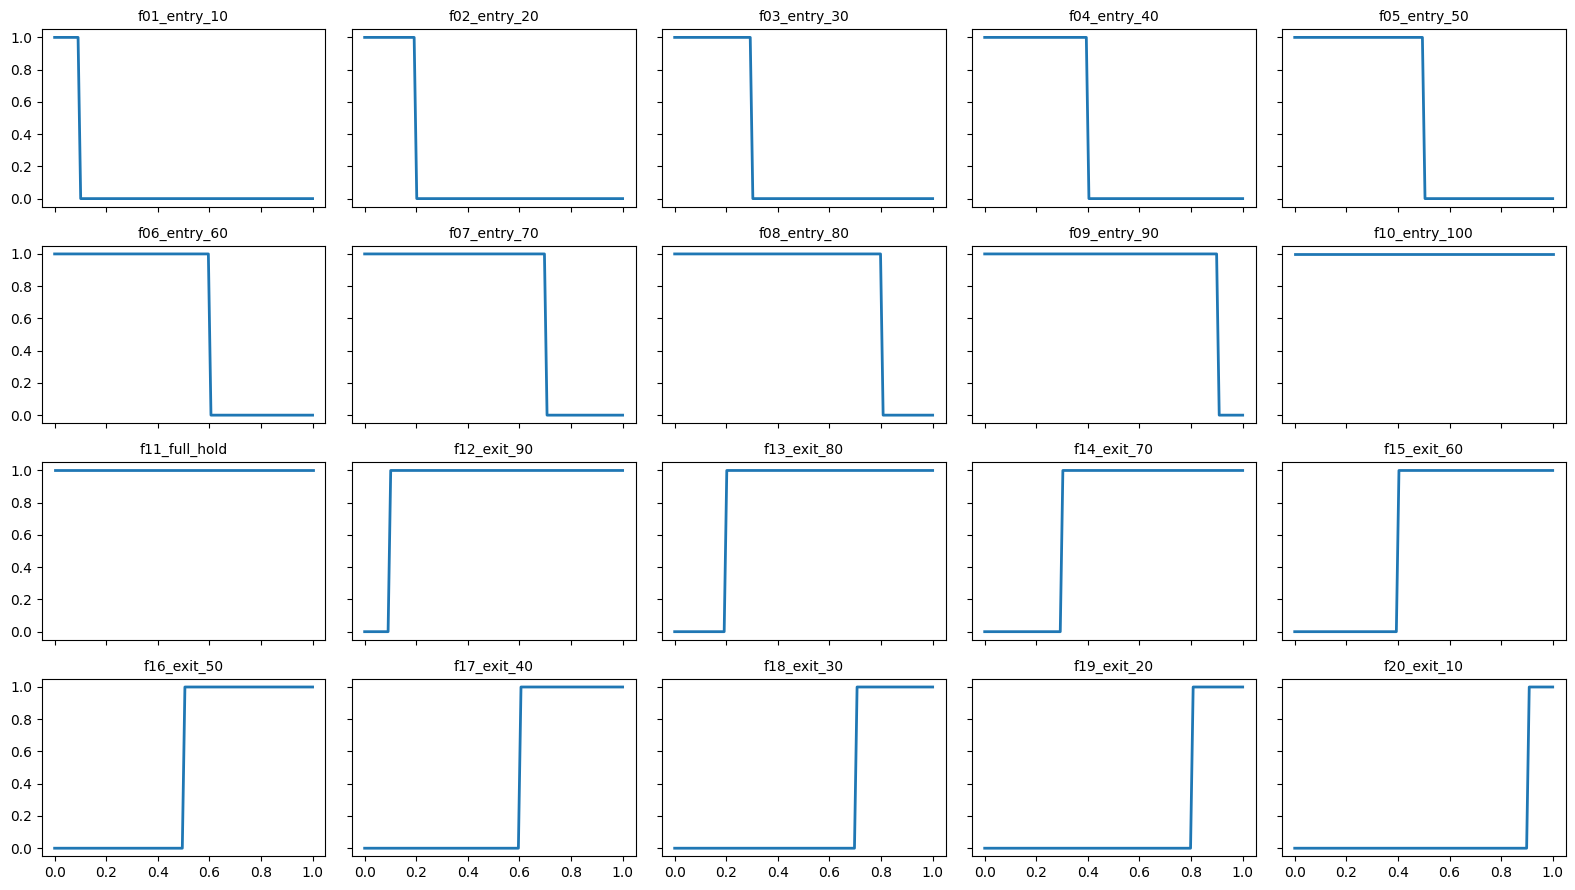

In [3]:

# ----------------------------
# FRAME TEMPLATES + SCORING
# ----------------------------
def make_20_frame_templates(n=100):
    '''
    20 total frames:
    10 entry-like frames
    1 full hold frame
    9 exit-like frames
    '''
    templates = []

    # entry: [0, 0.1] ... [0, 1.0]
    for i in range(1, 11):
        frac = i / 10.0
        t = np.zeros(n, dtype=float)
        t[:max(1, int(round(frac * n)))] = 1.0
        templates.append({
            "frame_idx": i,
            "frame_name": f"f{i:02d}_entry_{int(frac*100):02d}",
            "frame_kind": "entry",
            "start_frac": 0.0,
            "end_frac": frac,
            "template": t,
        })

    # full hold
    templates.append({
        "frame_idx": 11,
        "frame_name": "f11_full_hold",
        "frame_kind": "hold",
        "start_frac": 0.0,
        "end_frac": 1.0,
        "template": np.ones(n, dtype=float),
    })

    # exit: [0.1, 1.0] ... [0.9, 1.0]
    for j, frac in enumerate(np.arange(0.1, 1.0, 0.1), start=12):
        t = np.ones(n, dtype=float)
        t[:int(round(frac * n))] = 0.0
        remain = int(round((1.0 - frac) * 100))

        templates.append({
            "frame_idx": j,
            "frame_name": f"f{j:02d}_exit_{remain:02d}",
            "frame_kind": "exit",
            "start_frac": float(frac),
            "end_frac": 1.0,
            "template": t,
        })

    return templates


FRAME_TEMPLATES = make_20_frame_templates(n=N_PROFILE)


def score_profile_against_template(profile_100, template_100):
    '''
    Lower score = better match.
    Uses a mix of:
    - cumulative distribution mismatch (EMD-like)
    - center-of-mass mismatch
    - direct L2 mismatch
    '''
    p = normalize_profile(profile_100)
    t = normalize_profile(template_100)

    if p.sum() <= 0 or t.sum() <= 0:
        return np.nan, np.nan, np.nan, np.nan

    cdf_p = np.cumsum(p)
    cdf_t = np.cumsum(t)

    emd_like = float(np.mean(np.abs(cdf_p - cdf_t)))
    com_dist = float(abs(profile_center_of_mass(p) - profile_center_of_mass(t)))
    l2_dist = float(np.linalg.norm(p - t))

    score = W_EMD * emd_like + W_COM * com_dist + W_L2 * l2_dist
    return score, emd_like, com_dist, l2_dist


def plot_frame_templates():
    fig, axes = plt.subplots(4, 5, figsize=(16, 9), sharex=True, sharey=True)
    axes = axes.ravel()

    x = np.linspace(0, 1, N_PROFILE)

    for ax, spec in zip(axes, FRAME_TEMPLATES):
        ax.plot(x, spec["template"], linewidth=2)
        ax.set_title(spec["frame_name"], fontsize=10)
        ax.set_ylim(-0.05, 1.05)

    for ax in axes[len(FRAME_TEMPLATES):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_frame_templates()


In [4]:

# ----------------------------
# LOAD METADATA + PREPARE PROFILES
# ----------------------------
df = pd.read_csv(CSV_PATH).copy()

df["pt_bins_arr"] = df[PT_BINS_COL].apply(lambda x: parse_vec(x, dtype=int))
df["pt_widths_arr"] = df[PT_WIDTHS_COL].apply(lambda x: parse_vec(x, dtype=float))
df["pt_center_bin_num"] = pd.to_numeric(df[PT_CENTER_COL], errors="coerce")
df["unique_key"] = df.apply(build_unique_key, axis=1)

df["vec_len_match"] = df["pt_bins_arr"].apply(len) == df["pt_widths_arr"].apply(len)

# determine period length from observed max bin
PERIOD_LENGTH = int(df["pt_bins_arr"].apply(lambda a: a.max() if len(a) else -1).max() + 1)

df["linear_profile"] = df.apply(
    lambda r: linearize_profile(r["pt_bins_arr"], r["pt_widths_arr"], PERIOD_LENGTH),
    axis=1,
)
df["centered_profile"] = df.apply(
    lambda r: centered_profile(r["linear_profile"], r["pt_center_bin_num"]),
    axis=1,
)
df["profile_100"] = df["linear_profile"].apply(lambda v: resample_profile(v, n=N_PROFILE))
df["profile_100_norm"] = df["profile_100"].apply(normalize_profile)
df["profile_com"] = df["profile_100_norm"].apply(profile_center_of_mass)

print("Rows:", len(df))
print("Period length:", PERIOD_LENGTH)
print("Vector length matches:", int(df["vec_len_match"].sum()), "/", len(df))
print("Unique objects:", df["unique_key"].nunique())

display(
    df[[
        "unique_key",
        BG_COL,
        DAPI_COL,
        PT_CENTER_COL,
        "vec_len_match",
        "profile_com",
    ]].head()
)


Rows: 410
Period length: 17
Vector length matches: 410 / 410
Unique objects: 410


,unique_key,path_background,path_dapi,pseudotime_center_bin,vec_len_match,profile_com
0,img00001_obj00001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,16,True,0.444754
1,img00002_obj00001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,11,True,0.490811
2,img00002_obj00002,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,5,True,0.449492
3,img00003_obj00001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,15,True,0.472672
4,img00004_obj00001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,16,True,0.466351


In [5]:

# ----------------------------
# SCORE EVERY OBJECT AGAINST EVERY FRAME
# ----------------------------
candidate_rows = []

for idx, row in df.iterrows():
    profile_100 = row["profile_100"]

    for spec in FRAME_TEMPLATES:
        score, emd_like, com_dist, l2_dist = score_profile_against_template(
            profile_100,
            spec["template"]
        )

        candidate_rows.append({
            "row_idx": idx,
            "unique_key": row["unique_key"],
            "frame_idx": spec["frame_idx"],
            "frame_name": spec["frame_name"],
            "frame_kind": spec["frame_kind"],
            "start_frac": spec["start_frac"],
            "end_frac": spec["end_frac"],
            "score": score,
            "emd_like": emd_like,
            "com_dist": com_dist,
            "l2_dist": l2_dist,
            "profile_com": row["profile_com"],
            PT_CENTER_COL: row["pt_center_bin_num"],
            BG_COL: row[BG_COL],
            DAPI_COL: row[DAPI_COL],
        })

candidates = pd.DataFrame(candidate_rows)
candidates["rank_within_frame"] = (
    candidates.groupby("frame_name")["score"]
    .rank(method="first", ascending=True)
)

summary_counts = (
    candidates.groupby("frame_name")
    .size()
    .rename("n_candidates_scored")
    .reset_index()
)

summary_best = (
    candidates.sort_values(["frame_name", "score"])
    .groupby("frame_name")
    .head(10)
    .copy()
)

display(summary_counts)
display(summary_best[[
    "frame_name", "rank_within_frame", "unique_key", "score",
    "emd_like", "com_dist", "l2_dist", PT_CENTER_COL
]].head(30))


,frame_name,n_candidates_scored
0,f01_entry_10,410
1,f02_entry_20,410
2,f03_entry_30,410
3,f04_entry_40,410
4,f05_entry_50,410
5,f06_entry_60,410
6,f07_entry_70,410
7,f08_entry_80,410
8,f09_entry_90,410
9,f10_entry_100,410


,frame_name,rank_within_frame,unique_key,score,emd_like,com_dist,l2_dist,pseudotime_center_bin
5320,f01_entry_10,1.0,img00265_obj00002,0.181423,0.166759,0.168443,0.237551,3
4360,f01_entry_10,2.0,img00223_obj00001,0.231779,0.226266,0.228552,0.250400,4
6000,f01_entry_10,3.0,img00300_obj00001,0.264599,0.264033,0.266700,0.262863,5
7340,f01_entry_10,4.0,img00369_obj00001,0.277248,0.280908,0.283745,0.258351,5
4760,f01_entry_10,5.0,img00242_obj00001,0.277843,0.281956,0.284804,0.257120,6
4300,f01_entry_10,6.0,img00220_obj00001,0.288139,0.292639,0.295595,0.265703,5
4240,f01_entry_10,7.0,img00216_obj00001,0.293050,0.300369,0.303404,0.259223,6
3220,f01_entry_10,8.0,img00165_obj00001,0.299103,0.307368,0.310473,0.261383,6
4560,f01_entry_10,9.0,img00232_obj00001,0.310049,0.321133,0.324376,0.260847,1
6300,f01_entry_10,10.0,img00315_obj00001,0.310729,0.320084,0.323317,0.268462,6


In [6]:

# ----------------------------
# VISUAL INSPECTION HELPERS
# ----------------------------
def build_candidate_preview(row_idx, frame_name):
    row = df.loc[row_idx]
    spec = next(s for s in FRAME_TEMPLATES if s["frame_name"] == frame_name)

    bg = to_2d(read_image(row[BG_COL]))
    dapi = to_2d(read_image(row[DAPI_COL]))

    if bg.shape != dapi.shape:
        raise ValueError(
            f"Shape mismatch for {row['unique_key']}: background {bg.shape}, dapi {dapi.shape}"
        )

    overlay, dapi_disp, dapi_enh = make_overlay_fixed_dapi(
        bg,
        dapi,
        bf_weight=BF_WEIGHT,
        dapi_gain=DAPI_GAIN,
        invert_bf=INVERT_BF,
        dapi_fixed_max=DAPI_FIXED_MAX
    )

    overlay_crop = crop_from_signal(overlay, dapi_enh, thr=CROP_THR, pad=CROP_PAD)
    dapi_crop = crop_from_signal(dapi_disp, dapi_enh, thr=CROP_THR, pad=CROP_PAD)

    return {
        "row": row,
        "spec": spec,
        "bg": bg,
        "dapi": dapi,
        "overlay": overlay,
        "overlay_crop": overlay_crop,
        "dapi_crop": dapi_crop,
    }


def plot_centered_profile(ax, centered_profile_vec, frame_spec, title=None):
    y = np.asarray(centered_profile_vec, dtype=float)
    x = np.arange(len(y))

    ax.bar(x, y, width=0.9)
    ax.axhline(0, linewidth=1)

    start = int(round(frame_spec["start_frac"] * len(y)))
    end = int(round(frame_spec["end_frac"] * len(y)))
    end = max(start + 1, end)

    ax.axvspan(start, end, alpha=0.15, color="red")
    if title is not None:
        ax.set_title(title, fontsize=10)


def preview_frame_candidates(frame_name, n=6):
    sub = candidates.loc[candidates["frame_name"] == frame_name].sort_values("score").head(n)

    fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(12, 3.2 * n))

    if n == 1:
        axes = np.array([axes])

    for ax_row, (_, cand) in zip(axes, sub.iterrows()):
        row_idx = int(cand["row_idx"])
        pack = build_candidate_preview(row_idx, frame_name)
        row = pack["row"]
        spec = pack["spec"]

        ax_row[0].imshow(pack["overlay_crop"])
        ax_row[0].set_title(f"{row['unique_key']}\nscore={cand['score']:.4f}")
        ax_row[0].axis("off")

        ax_row[1].imshow(pack["dapi_crop"], cmap="gray")
        ax_row[1].set_title("Fixed-scale DAPI crop")
        ax_row[1].axis("off")

        plot_centered_profile(
            ax_row[2],
            row["centered_profile"],
            spec,
            title=f"{frame_name} | center_bin={row['pt_center_bin_num']}"
        )

    plt.tight_layout()
    plt.show()


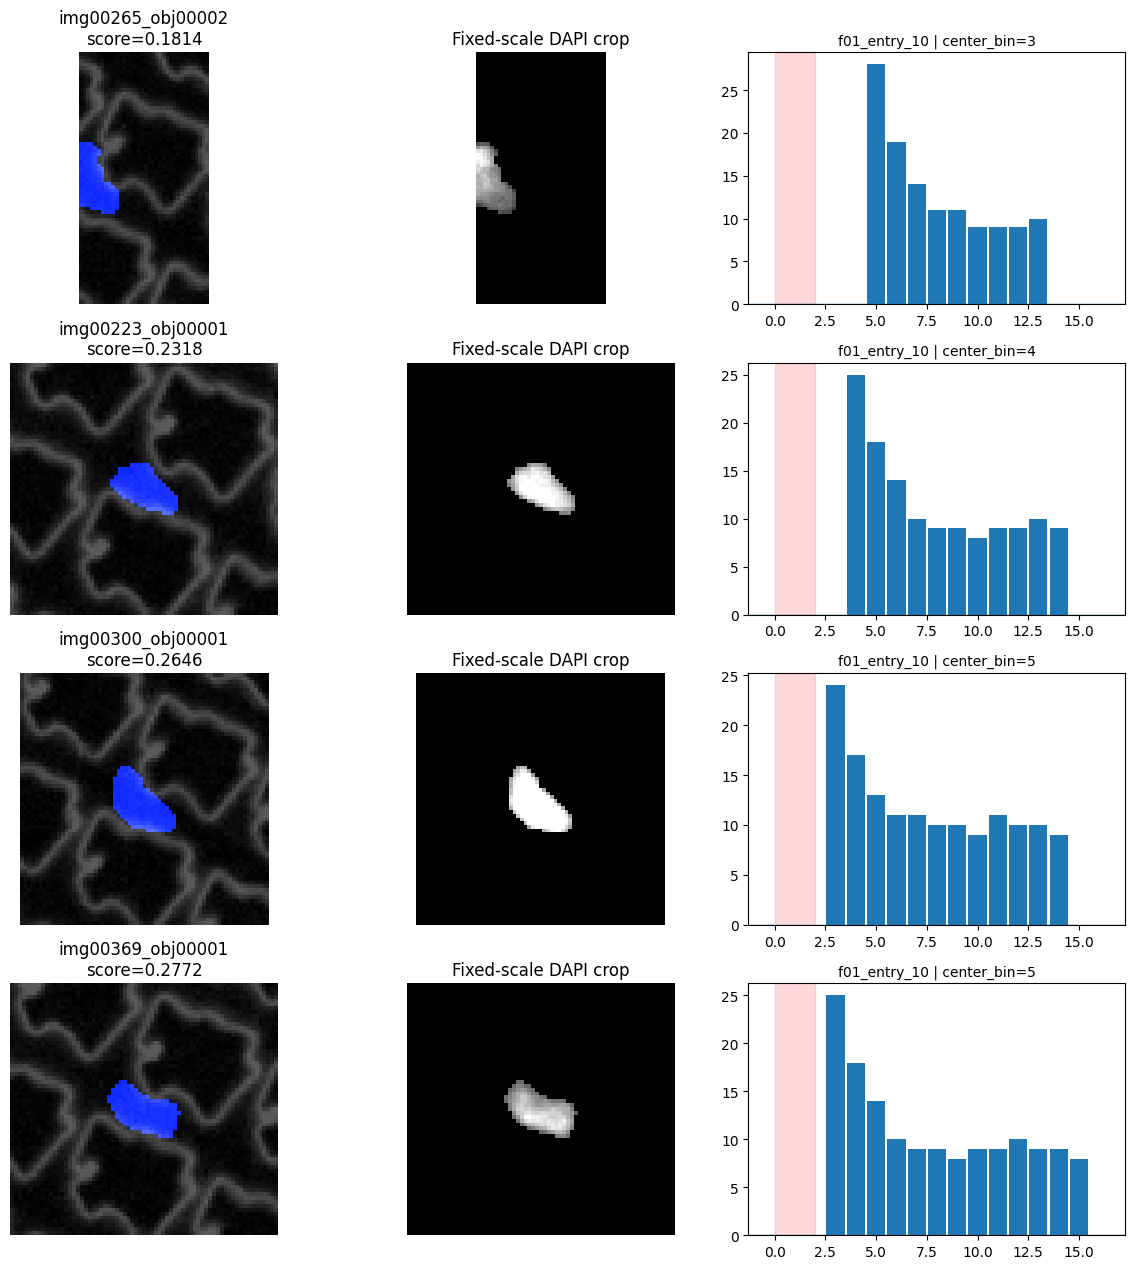

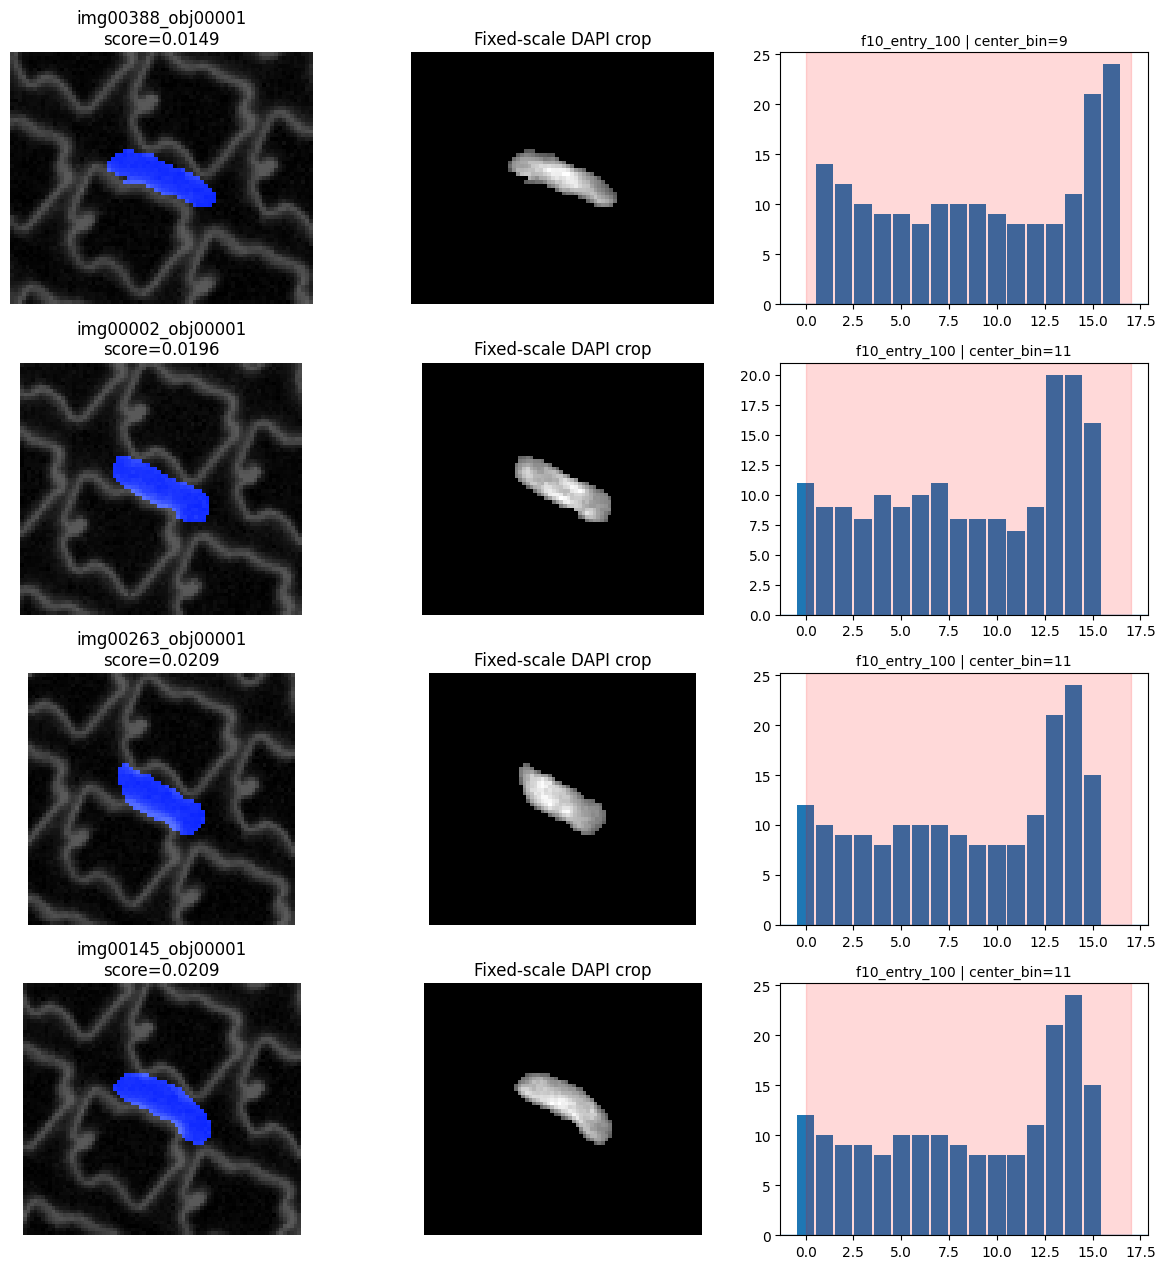

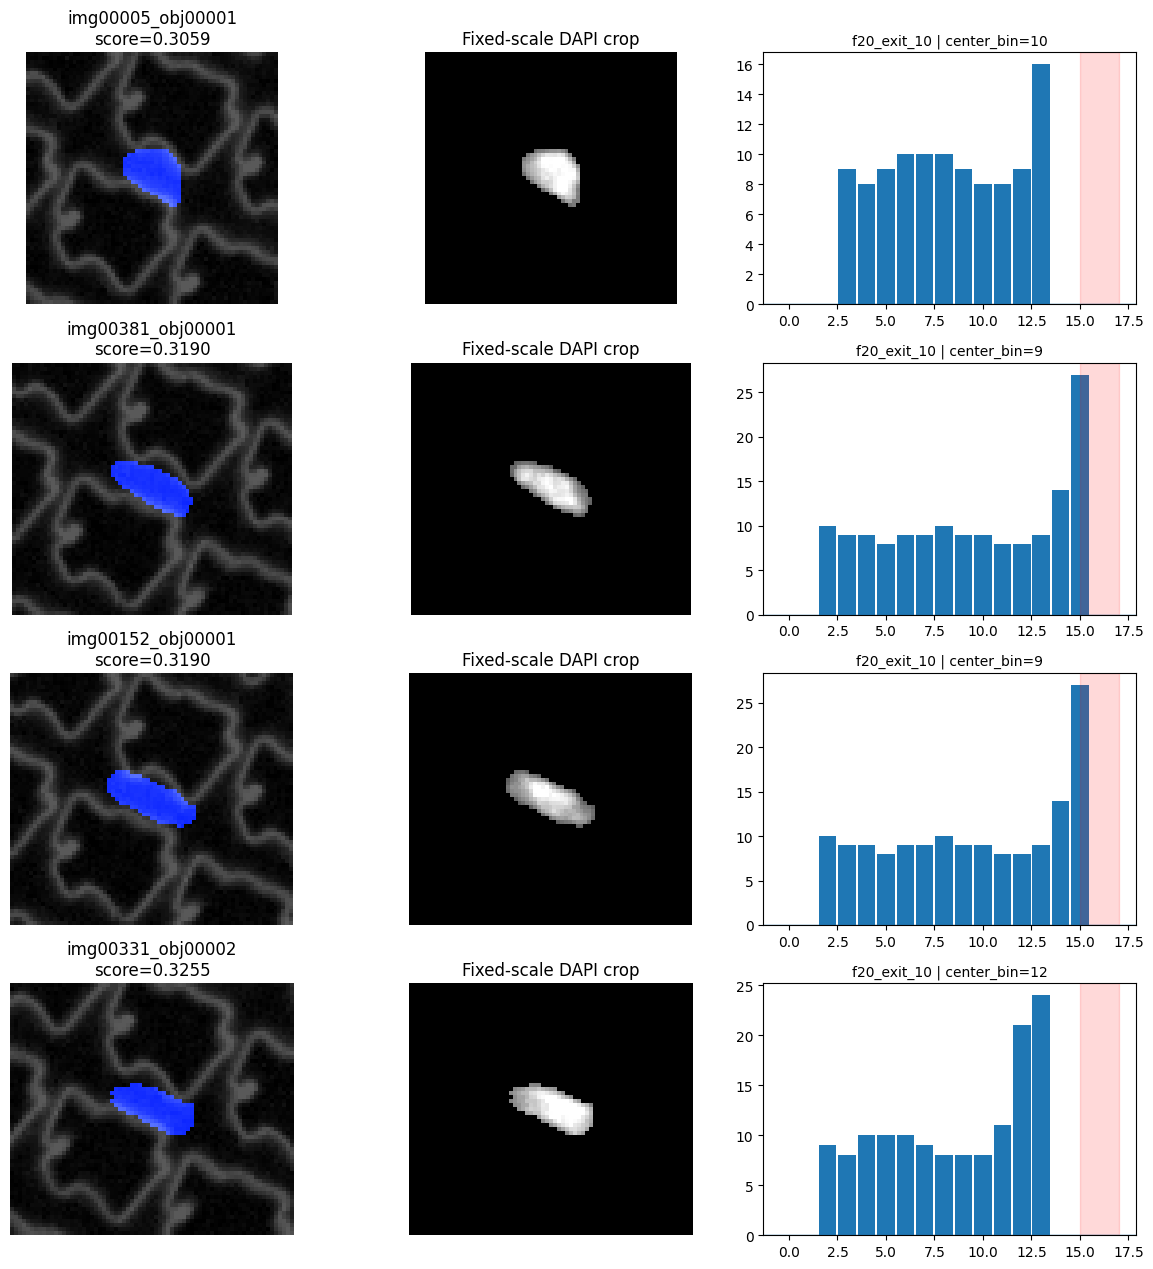

In [7]:

# Example preview:
preview_frame_candidates("f01_entry_10", n=4)
preview_frame_candidates("f10_entry_100", n=4)
preview_frame_candidates("f20_exit_10", n=4)


In [8]:

# ----------------------------
# EXPORT HELPERS
# ----------------------------
def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def export_single_candidate_png(row_idx, frame_name, out_path, score):
    pack = build_candidate_preview(row_idx, frame_name)
    row = pack["row"]
    spec = pack["spec"]

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

    axes[0].imshow(pack["overlay_crop"])
    axes[0].set_title(f"{frame_name}\n{row['unique_key']}\nscore={score:.4f}")
    axes[0].axis("off")

    axes[1].imshow(pack["dapi_crop"], cmap="gray")
    axes[1].set_title("Fixed-scale DAPI crop")
    axes[1].axis("off")

    plot_centered_profile(
        axes[2],
        row["centered_profile"],
        spec,
        title=f"center_bin={row['pt_center_bin_num']}"
    )

    plt.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)


def export_contact_sheet(frame_name, frame_df, out_path, rows_per_page=10):
    n = len(frame_df)
    nrows = min(rows_per_page, n)

    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(12, 3.1 * nrows))
    if nrows == 1:
        axes = np.array([axes])

    for ax_row in axes:
        for ax in ax_row:
            ax.axis("off")

    for r, (_, cand) in enumerate(frame_df.head(rows_per_page).iterrows()):
        row_idx = int(cand["row_idx"])
        pack = build_candidate_preview(row_idx, frame_name)
        row = pack["row"]
        spec = pack["spec"]

        axes[r, 0].imshow(pack["overlay_crop"])
        axes[r, 0].set_title(f"{row['unique_key']} | score={cand['score']:.4f}")
        axes[r, 0].axis("off")

        plot_centered_profile(
            axes[r, 1],
            row["centered_profile"],
            spec,
            title=f"{frame_name} | center_bin={row['pt_center_bin_num']}"
        )

    plt.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)


def export_frame_groups(candidates_df, out_dir, top_k_per_frame=50, rows_per_contact_sheet=10):
    out_dir = ensure_dir(out_dir)

    manifest_all = []
    summary_rows = []

    for spec in FRAME_TEMPLATES:
        frame_name = spec["frame_name"]
        frame_dir = ensure_dir(out_dir / frame_name)

        sub = (
            candidates_df.loc[candidates_df["frame_name"] == frame_name]
            .sort_values("score", ascending=True)
            .copy()
        )

        if top_k_per_frame is not None:
            sub = sub.head(top_k_per_frame).copy()

        exported_rows = []
        export_rank = 0

        for _, cand in sub.iterrows():
            row_idx = int(cand["row_idx"])
            row = df.loc[row_idx]

            try:
                # quick file validation before export
                _ = to_2d(read_image(row[BG_COL]))
                _ = to_2d(read_image(row[DAPI_COL]))

                export_rank += 1
                png_name = f"candidate_{export_rank:04d}_{row['unique_key']}.png"
                png_path = frame_dir / png_name

                export_single_candidate_png(
                    row_idx=row_idx,
                    frame_name=frame_name,
                    out_path=png_path,
                    score=float(cand["score"])
                )

                record = {
                    "frame_name": frame_name,
                    "export_rank": export_rank,
                    "row_idx": row_idx,
                    "unique_key": row["unique_key"],
                    BG_COL: row[BG_COL],
                    DAPI_COL: row[DAPI_COL],
                    PT_CENTER_COL: row["pt_center_bin_num"],
                    "score": float(cand["score"]),
                    "emd_like": float(cand["emd_like"]),
                    "com_dist": float(cand["com_dist"]),
                    "l2_dist": float(cand["l2_dist"]),
                    "png_name": png_name,
                    "selected": 0,
                }
                exported_rows.append(record)
                manifest_all.append(record)

            except Exception as e:
                exported_rows.append({
                    "frame_name": frame_name,
                    "export_rank": np.nan,
                    "row_idx": row_idx,
                    "unique_key": row["unique_key"],
                    "score": float(cand["score"]),
                    "error": str(e),
                    "selected": 0,
                })

        frame_manifest = pd.DataFrame(exported_rows)
        frame_manifest.to_csv(frame_dir / "metadata.csv", index=False)

        successful = frame_manifest["png_name"].notna().sum() if "png_name" in frame_manifest.columns else 0

        if successful > 0:
            contact_path = frame_dir / "contact_sheet_001.png"
            ok_rows = frame_manifest.loc[frame_manifest["png_name"].notna()].copy()
            ok_rows = ok_rows.merge(
                sub[["row_idx", "score"]].drop_duplicates(),
                on=["row_idx", "score"],
                how="left"
            )
            export_contact_sheet(frame_name, ok_rows, contact_path, rows_per_page=rows_per_contact_sheet)

        summary_rows.append({
            "frame_name": frame_name,
            "n_scored": int((candidates_df["frame_name"] == frame_name).sum()),
            "n_exported": int(successful),
            "top_k_limit": top_k_per_frame if top_k_per_frame is not None else "all",
        })

    pd.DataFrame(summary_rows).to_csv(out_dir / "summary_counts.csv", index=False)
    pd.DataFrame(manifest_all).to_csv(out_dir / "summary_best_candidates.csv", index=False)

    print(f"Export finished: {out_dir}")


In [9]:

# ----------------------------
# RUN EXPORT
# ----------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)

export_frame_groups(
    candidates_df=candidates,
    out_dir=OUT_DIR,
    top_k_per_frame=TOP_K_PER_FRAME,
    rows_per_contact_sheet=ROWS_PER_CONTACT_SHEET
)


Export finished: 1462_frame_candidate_search_output_020426



## Notes for the next phase

This notebook creates **candidate pools** only.

It does **not** yet:
- enforce one-object-only usage across the final sequence
- rank a full 20-frame sequence jointly
- use `cp_measure` morphology similarity across frame groups
- assemble the final GIF

Those belong in the next notebook or next section:
1. manual selection
2. semi-automated full-sequence matching
3. final GIF export


## Stabilized GIF builder

This section adds:

- automatic 20-frame sequence selection
- optional smoother sequence mode (`SEQUENCE_MODE = "greedy_smooth"`)
- fixed-size centroid-anchored crops to reduce frame-to-frame jitter
- GIF export and display

Run all previous cells first so that these variables and functions already exist:

- `OUT_DIR`
- `candidates`
- `FRAME_TEMPLATES`
- `build_candidate_preview`
- `plot_centered_profile`
- `df`

In [10]:
# ============================================================
# STABILIZED GIF BUILD
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio

from pathlib import Path
from PIL import Image


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
GIF_DIR = OUT_DIR / "gif_build_stabilized"
GIF_DIR.mkdir(parents=True, exist_ok=True)

GIF_FRAME_SIZE = (980, 360)      # final GIF canvas: (width, height)
GIF_FRAME_DURATION = 0.005         # seconds per frame
GIF_HOLD_MIDDLE_N = 2            # extra repeats for the full state
GIF_HOLD_LAST_N = 6              # extra repeats for the last frame

OVERLAY_CROP_HW = (220, 220)     # fixed crop size for overlay panel
DAPI_CROP_HW = (180, 180)        # fixed crop size for DAPI panel

DAPI_MASK_REL_THRESHOLD = 0.15   # threshold relative to max intensity
SEQUENCE_MODE = "greedy"         # "greedy" or "greedy_smooth"


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def frame_name_to_index(frame_name):
    m = re.match(r"^f(\d+)_", str(frame_name))
    if m:
        return int(m.group(1))
    return 9999


def get_frame_order(frame_templates):
    names = []
    for spec in frame_templates:
        if isinstance(spec, dict):
            names.append(spec["frame_name"])
        else:
            names.append(spec[0])
    return names


def pad_to_canvas(img, out_w, out_h, bg_value=255):
    arr = np.asarray(img)

    if arr.ndim == 2:
        canvas = np.full((out_h, out_w), bg_value, dtype=arr.dtype)
    else:
        canvas = np.full((out_h, out_w, arr.shape[2]), bg_value, dtype=arr.dtype)

    h, w = arr.shape[:2]
    if h == 0 or w == 0:
        return canvas

    scale = min(out_w / w, out_h / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    pil = Image.fromarray(arr)
    pil = pil.resize((new_w, new_h), resample=Image.BILINEAR)
    arr2 = np.asarray(pil)

    y0 = (out_h - new_h) // 2
    x0 = (out_w - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = arr2
    return canvas


def make_binary_mask_from_dapi(dapi_img, rel_thr=DAPI_MASK_REL_THRESHOLD):
    arr = np.asarray(dapi_img).astype(np.float32)
    if arr.size == 0:
        return np.zeros_like(arr, dtype=bool)

    vmax = float(arr.max())
    if vmax <= 0:
        return np.zeros_like(arr, dtype=bool)

    thr = vmax * rel_thr
    return arr > thr


def mask_centroid(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    return float(ys.mean()), float(xs.mean())


def fixed_center_crop(arr, center_y, center_x, crop_h, crop_w, fill_value=0):
    arr = np.asarray(arr)
    H, W = arr.shape[:2]

    y0 = int(round(center_y - crop_h / 2))
    x0 = int(round(center_x - crop_w / 2))
    y1 = y0 + crop_h
    x1 = x0 + crop_w

    src_y0 = max(0, y0)
    src_x0 = max(0, x0)
    src_y1 = min(H, y1)
    src_x1 = min(W, x1)

    dst_y0 = src_y0 - y0
    dst_x0 = src_x0 - x0
    dst_y1 = dst_y0 + (src_y1 - src_y0)
    dst_x1 = dst_x0 + (src_x1 - src_x0)

    if arr.ndim == 2:
        out = np.full((crop_h, crop_w), fill_value, dtype=arr.dtype)
        out[dst_y0:dst_y1, dst_x0:dst_x1] = arr[src_y0:src_y1, src_x0:src_x1]
    else:
        if np.isscalar(fill_value):
            fill = [fill_value] * arr.shape[2]
        else:
            fill = fill_value

        out = np.zeros((crop_h, crop_w, arr.shape[2]), dtype=arr.dtype)
        for c in range(arr.shape[2]):
            out[..., c] = fill[c]
        out[dst_y0:dst_y1, dst_x0:dst_x1] = arr[src_y0:src_y1, src_x0:src_x1]

    return out


def stabilize_candidate_pack(pack, overlay_hw=OVERLAY_CROP_HW, dapi_hw=DAPI_CROP_HW):
    overlay = np.asarray(pack["overlay_crop"])
    dapi = np.asarray(pack["dapi_crop"])

    mask = make_binary_mask_from_dapi(dapi)
    cycx = mask_centroid(mask)

    if cycx is None:
        cy = dapi.shape[0] / 2
        cx = dapi.shape[1] / 2
    else:
        cy, cx = cycx

    overlay_fill = [255, 255, 255] if overlay.ndim == 3 else 255

    overlay_stab = fixed_center_crop(
        overlay,
        cy, cx,
        overlay_hw[0], overlay_hw[1],
        fill_value=overlay_fill
    )

    dapi_stab = fixed_center_crop(
        dapi,
        cy, cx,
        dapi_hw[0], dapi_hw[1],
        fill_value=0
    )

    return {
        **pack,
        "overlay_crop_stab": overlay_stab,
        "dapi_crop_stab": dapi_stab,
        "dapi_mask_stab": make_binary_mask_from_dapi(dapi_stab),
        "stabilized_centroid_yx": (cy, cx),
    }


# ------------------------------------------------------------
# SEQUENCE SELECTION
# ------------------------------------------------------------
FRAME_ORDER = get_frame_order(FRAME_TEMPLATES)


def select_unique_greedy_sequence(candidates_df, frame_order):
    selected_rows = []
    used_keys = set()

    for frame_name in frame_order:
        sub = (
            candidates_df.loc[candidates_df["frame_name"] == frame_name]
            .sort_values(["score", "rank_within_frame"], ascending=[True, True])
            .copy()
        )

        chosen = None
        for _, r in sub.iterrows():
            if r["unique_key"] not in used_keys:
                chosen = r
                break

        if chosen is None:
            print(f"WARNING: no unused candidate found for {frame_name}")
            continue

        selected_rows.append(chosen)
        used_keys.add(chosen["unique_key"])

    seq = pd.DataFrame(selected_rows).reset_index(drop=True)

    if "frame_idx" not in seq.columns:
        seq["frame_idx"] = seq["frame_name"].apply(frame_name_to_index)

    return seq


def estimate_pack_features(pack):
    mask = pack["dapi_mask_stab"]
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return {
            "cx": np.nan,
            "cy": np.nan,
            "area": 0.0,
            "w": 0.0,
            "h": 0.0,
        }

    cx = float(xs.mean())
    cy = float(ys.mean())
    area = float(mask.sum())
    w = float(xs.max() - xs.min() + 1)
    h = float(ys.max() - ys.min() + 1)

    return {
        "cx": cx,
        "cy": cy,
        "area": area,
        "w": w,
        "h": h,
    }


def smooth_cost(prev_feat, curr_feat):
    if prev_feat is None:
        return 0.0

    cx_cost = abs(curr_feat["cx"] - prev_feat["cx"])
    cy_cost = abs(curr_feat["cy"] - prev_feat["cy"])
    area_cost = abs(curr_feat["area"] - prev_feat["area"]) / max(1.0, prev_feat["area"])
    w_cost = abs(curr_feat["w"] - prev_feat["w"]) / max(1.0, prev_feat["w"])
    h_cost = abs(curr_feat["h"] - prev_feat["h"]) / max(1.0, prev_feat["h"])

    return (
        0.8 * cx_cost +
        0.8 * cy_cost +
        20.0 * area_cost +
        8.0 * w_cost +
        8.0 * h_cost
    )


def select_unique_greedy_smooth_sequence(candidates_df, frame_order, top_k_per_frame=12):
    selected_rows = []
    used_keys = set()
    prev_feat = None

    for frame_name in frame_order:
        sub = (
            candidates_df.loc[candidates_df["frame_name"] == frame_name]
            .sort_values(["score", "rank_within_frame"], ascending=[True, True])
            .copy()
            .head(top_k_per_frame)
        )

        best_row = None
        best_total = np.inf
        best_feat = None

        for _, r in sub.iterrows():
            if r["unique_key"] in used_keys:
                continue

            pack = build_candidate_preview(int(r["row_idx"]), r["frame_name"])
            pack = stabilize_candidate_pack(pack)
            feat = estimate_pack_features(pack)

            continuity = smooth_cost(prev_feat, feat)
            total = float(r["score"]) + 0.015 * continuity

            if total < best_total:
                best_total = total
                best_row = r
                best_feat = feat

        if best_row is None:
            print(f"WARNING: no unused candidate found for {frame_name}")
            continue

        selected_rows.append(best_row)
        used_keys.add(best_row["unique_key"])
        prev_feat = best_feat

    seq = pd.DataFrame(selected_rows).reset_index(drop=True)

    if "frame_idx" not in seq.columns:
        seq["frame_idx"] = seq["frame_name"].apply(frame_name_to_index)

    return seq


if SEQUENCE_MODE == "greedy_smooth":
    sequence_auto = select_unique_greedy_smooth_sequence(candidates, FRAME_ORDER, top_k_per_frame=12)
else:
    sequence_auto = select_unique_greedy_sequence(candidates, FRAME_ORDER)

sequence_auto = sequence_auto.sort_values("frame_idx").reset_index(drop=True)

display(sequence_auto[[
    "frame_idx", "frame_name", "unique_key", "score", "pseudotime_center_bin"
]])
print("Frames selected:", len(sequence_auto))
print("Unique objects used:", sequence_auto["unique_key"].nunique())

,frame_idx,frame_name,unique_key,score,pseudotime_center_bin
0,1,f01_entry_10,img00265_obj00002,0.181423,3
1,2,f02_entry_20,img00223_obj00001,0.171796,4
2,3,f03_entry_30,img00300_obj00001,0.155772,5
3,4,f04_entry_40,img00369_obj00001,0.125243,5
4,5,f05_entry_50,img00242_obj00001,0.087664,6
5,6,f06_entry_60,img00220_obj00001,0.054567,5
6,7,f07_entry_70,img00216_obj00001,0.037202,6
7,8,f08_entry_80,img00315_obj00001,0.034189,6
8,9,f09_entry_90,img00307_obj00001,0.019584,7
9,10,f10_entry_100,img00388_obj00001,0.014918,9


Frames selected: 20
Unique objects used: 20


In [11]:
# ------------------------------------------------------------
# RENDER STABILIZED GIF FRAMES
# ------------------------------------------------------------
def render_sequence_frame(row, out_path=None):
    pack = build_candidate_preview(int(row["row_idx"]), row["frame_name"])
    pack = stabilize_candidate_pack(pack)

    spec = pack["spec"]
    meta_row = pack["row"]

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

    axes[0].imshow(pack["overlay_crop_stab"])
    axes[0].set_title(
        f"{row['frame_name']}\n{meta_row['unique_key']}\nscore={row['score']:.4f}"
    )
    axes[0].axis("off")

    axes[1].imshow(pack["dapi_crop_stab"], cmap="gray")
    axes[1].set_title("Fixed-scale DAPI crop")
    axes[1].axis("off")

    plot_centered_profile(
        axes[2],
        meta_row["centered_profile"],
        spec,
        title=f"center_bin={meta_row['pt_center_bin_num']}"
    )

    plt.tight_layout()

    tmp_path = GIF_DIR / "_tmp_frame.png"
    fig.savefig(tmp_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    arr = imageio.imread(tmp_path)
    arr = pad_to_canvas(arr, GIF_FRAME_SIZE[0], GIF_FRAME_SIZE[1], bg_value=255)

    if out_path is not None:
        imageio.imwrite(out_path, arr)

    return arr

In [12]:
# ------------------------------------------------------------
# BUILD AND SAVE THE STABILIZED GIF
# ------------------------------------------------------------
gif_frames = []
GIF_FRAME_DURATION=0.002
for _, row in sequence_auto.iterrows():
    out_png = GIF_DIR / f"{int(row['frame_idx']):02d}_{row['frame_name']}.png"
    frame_arr = render_sequence_frame(row, out_path=out_png)
    gif_frames.append(frame_arr)

    if str(row["frame_name"]) in {"f10_entry_100", "f11_full_hold"}:
        for _ in range(GIF_HOLD_MIDDLE_N):
            gif_frames.append(frame_arr)

for _ in range(GIF_HOLD_LAST_N):
    gif_frames.append(gif_frames[-1])

gif_path = GIF_DIR / "animation_auto_stabilized.gif"
imageio.mimsave(gif_path, gif_frames, duration=1.0/GIF_FRAME_DURATION, loop=0)

print("Saved GIF to:", gif_path)
gif_path

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB dat

Saved GIF to: 1462_frame_candidate_search_output_020426\gif_build_stabilized\animation_auto_stabilized.gif


WindowsPath('1462_frame_candidate_search_output_020426/gif_build_stabilized/animation_auto_stabilized.gif')

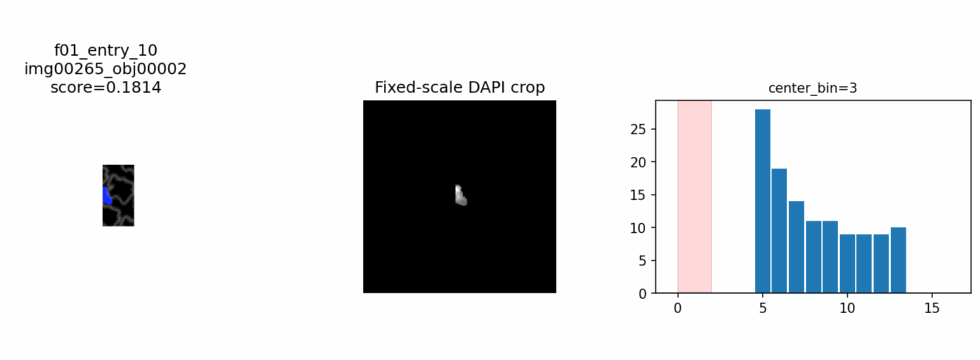

In [13]:
from IPython.display import Image as IPyImage, display

display(IPyImage(filename=str(gif_path)))

In [14]:
# ------------------------------------------------------------
# BUILD AND SAVE MULTIPLE STABILIZED GIFS
# ------------------------------------------------------------
import imageio.v2 as imageio
from pathlib import Path

GIF_FRAME_DURATION = 0.2   # seconds per frame
GIF_HOLD_MIDDLE_N = 2
GIF_HOLD_LAST_N = 6

def save_stabilized_gif(sequence_df, gif_name, gif_dir=GIF_DIR):
    gif_frames = []

    # optional: save individual PNG frames for this GIF in its own folder
    frame_dir = gif_dir / gif_name.replace(".gif", "")
    frame_dir.mkdir(parents=True, exist_ok=True)

    for _, row in sequence_df.iterrows():
        out_png = frame_dir / f"{int(row['frame_idx']):02d}_{row['frame_name']}.png"
        frame_arr = render_sequence_frame(row, out_path=out_png)
        gif_frames.append(frame_arr)

        if str(row["frame_name"]) in {"f10_entry_100", "f11_full_hold"}:
            for _ in range(GIF_HOLD_MIDDLE_N):
                gif_frames.append(frame_arr)

    for _ in range(GIF_HOLD_LAST_N):
        gif_frames.append(gif_frames[-1])

    gif_path = gif_dir / gif_name
    imageio.mimsave(gif_path, gif_frames, duration=1.0/GIF_FRAME_DURATION, loop=0)

    print("Saved GIF to:", gif_path)
    return gif_path

In [15]:
# ------------------------------------------------------------
# BUILD 15 STABILIZED GIFS:
# GIF 1 uses rank 1 from each frame,
# GIF 2 uses rank 2 from each frame, etc.
# If a unique_key repeats within one GIF, skip forward to next candidate.
# ------------------------------------------------------------

import imageio.v2 as imageio
import pandas as pd

N_GIFS = 15
GIF_FRAME_DURATION = 0.004   # seconds per frame (adjust as you like)

FRAME_ORDER = get_frame_order(FRAME_TEMPLATES)


def build_ranked_sequence(candidates_df, frame_order, rank_start=1):
    """
    Build one sequence by taking approximately the `rank_start`-th candidate
    from each frame. If that candidate's unique_key is already used in this GIF,
    move down the ranked list until a new unique_key is found.
    """
    selected_rows = []
    used_keys = set()

    for frame_name in frame_order:
        sub = (
            candidates_df.loc[candidates_df["frame_name"] == frame_name]
            .sort_values(["score", "rank_within_frame"], ascending=[True, True])
            .reset_index(drop=True)
            .copy()
        )

        if len(sub) == 0:
            print(f"WARNING: no candidates found for {frame_name}")
            continue

        # convert rank_start (1-based) to row index (0-based)
        start_idx = rank_start - 1

        if start_idx >= len(sub):
            print(f"WARNING: frame {frame_name} has fewer than {rank_start} candidates")
            continue

        chosen = None

        # first try from the requested rank onward
        for i in range(start_idx, len(sub)):
            r = sub.iloc[i]
            if r["unique_key"] not in used_keys:
                chosen = r
                break

        # fallback: if needed, search from the top again
        if chosen is None:
            for i in range(len(sub)):
                r = sub.iloc[i]
                if r["unique_key"] not in used_keys:
                    chosen = r
                    break

        if chosen is None:
            print(f"WARNING: could not find unused candidate for {frame_name}")
            continue

        selected_rows.append(chosen)
        used_keys.add(chosen["unique_key"])

    seq = pd.DataFrame(selected_rows).reset_index(drop=True)

    if len(seq) > 0 and "frame_idx" not in seq.columns:
        seq["frame_idx"] = seq["frame_name"].apply(frame_name_to_index)

    if len(seq) > 0:
        seq = seq.sort_values("frame_idx").reset_index(drop=True)

    return seq


def save_sequence_gif(sequence_df, gif_name, gif_dir=GIF_DIR):
    gif_frames = []

    gif_subdir = gif_dir / gif_name.replace(".gif", "")
    gif_subdir.mkdir(parents=True, exist_ok=True)

    for _, row in sequence_df.iterrows():
        out_png = gif_subdir / f"{int(row['frame_idx']):02d}_{row['frame_name']}.png"
        frame_arr = render_sequence_frame(row, out_path=out_png)
        gif_frames.append(frame_arr)

        if str(row["frame_name"]) in {"f10_entry_100", "f11_full_hold"}:
            for _ in range(GIF_HOLD_MIDDLE_N):
                gif_frames.append(frame_arr)

    if len(gif_frames) == 0:
        print(f"WARNING: no frames generated for {gif_name}")
        return None

    for _ in range(GIF_HOLD_LAST_N):
        gif_frames.append(gif_frames[-1])

    gif_path = gif_dir / gif_name
    imageio.mimsave(gif_path, gif_frames, duration=1.0/GIF_FRAME_DURATION, loop=0)

    print("Saved GIF to:", gif_path)
    return gif_path


# ------------------------------------------------------------
# GENERATE 15 GIFS
# ------------------------------------------------------------
gif_paths = []

for gif_rank in range(1, N_GIFS + 1):
    seq = build_ranked_sequence(candidates, FRAME_ORDER, rank_start=gif_rank)

    print(f"\nGIF {gif_rank}: {len(seq)} frames | unique objects = {seq['unique_key'].nunique() if len(seq) else 0}")
    display(seq[["frame_idx", "frame_name", "unique_key", "score"]])

    gif_name = f"animation_auto_stabilized_{gif_rank:02d}.gif"
    gif_path = save_sequence_gif(seq, gif_name)
    gif_paths.append(gif_path)

gif_paths


GIF 1: 20 frames | unique objects = 20


,frame_idx,frame_name,unique_key,score
0,1,f01_entry_10,img00265_obj00002,0.181423
1,2,f02_entry_20,img00223_obj00001,0.171796
2,3,f03_entry_30,img00300_obj00001,0.155772
3,4,f04_entry_40,img00369_obj00001,0.125243
4,5,f05_entry_50,img00242_obj00001,0.087664
5,6,f06_entry_60,img00220_obj00001,0.054567
6,7,f07_entry_70,img00216_obj00001,0.037202
7,8,f08_entry_80,img00315_obj00001,0.034189
8,9,f09_entry_90,img00307_obj00001,0.019584
9,10,f10_entry_100,img00388_obj00001,0.014918


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB dat

Saved GIF to: 1462_frame_candidate_search_output_020426\gif_build_stabilized\animation_auto_stabilized_01.gif

GIF 2: 20 frames | unique objects = 20


...

Saved GIF to: 1462_frame_candidate_search_output_020426\gif_build_stabilized\animation_auto_stabilized_14.gif

GIF 15: 20 frames | unique objects = 20


,frame_idx,frame_name,unique_key,score
0,1,f01_entry_10,img00107_obj00001,0.335770
1,2,f02_entry_20,img00042_obj00001,0.278894
2,3,f03_entry_30,img00261_obj00002,0.233997
3,4,f04_entry_40,img00150_obj00001,0.189554
4,5,f05_entry_50,img00050_obj00001,0.148340
5,6,f06_entry_60,img00232_obj00001,0.104855
6,7,f07_entry_70,img00268_obj00001,0.075255
7,8,f08_entry_80,img00248_obj00001,0.055442
8,9,f09_entry_90,img00030_obj00001,0.040727
9,10,f10_entry_100,img00358_obj00001,0.028926


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB dat

Saved GIF to: 1462_frame_candidate_search_output_020426\gif_build_stabilized\animation_auto_stabilized_15.gif


[WindowsPath('1462_frame_candidate_search_output_020426/gif_build_stabilized/animation_auto_stabilized_01.gif'),
 WindowsPath('1462_frame_candidate_search_output_020426/gif_build_stabilized/animation_auto_stabilized_02.gif'),
 WindowsPath('1462_frame_candidate_search_output_020426/gif_build_stabilized/animation_auto_stabilized_03.gif'),
 WindowsPath('1462_frame_candidate_search_output_020426/gif_build_stabilized/animation_auto_stabilized_04.gif'),
 WindowsPath('1462_frame_candidate_search_output_020426/gif_build_stabilized/animation_auto_stabilized_05.gif'),
 WindowsPath('1462_frame_candidate_search_output_020426/gif_build_stabilized/animation_auto_stabilized_06.gif'),
 WindowsPath('1462_frame_candidate_search_output_020426/gif_build_stabilized/animation_auto_stabilized_07.gif'),
 WindowsPath('1462_frame_candidate_search_output_020426/gif_build_stabilized/animation_auto_stabilized_08.gif'),
 WindowsPath('1462_frame_candidate_search_output_020426/gif_build_stabilized/animation_auto_stab

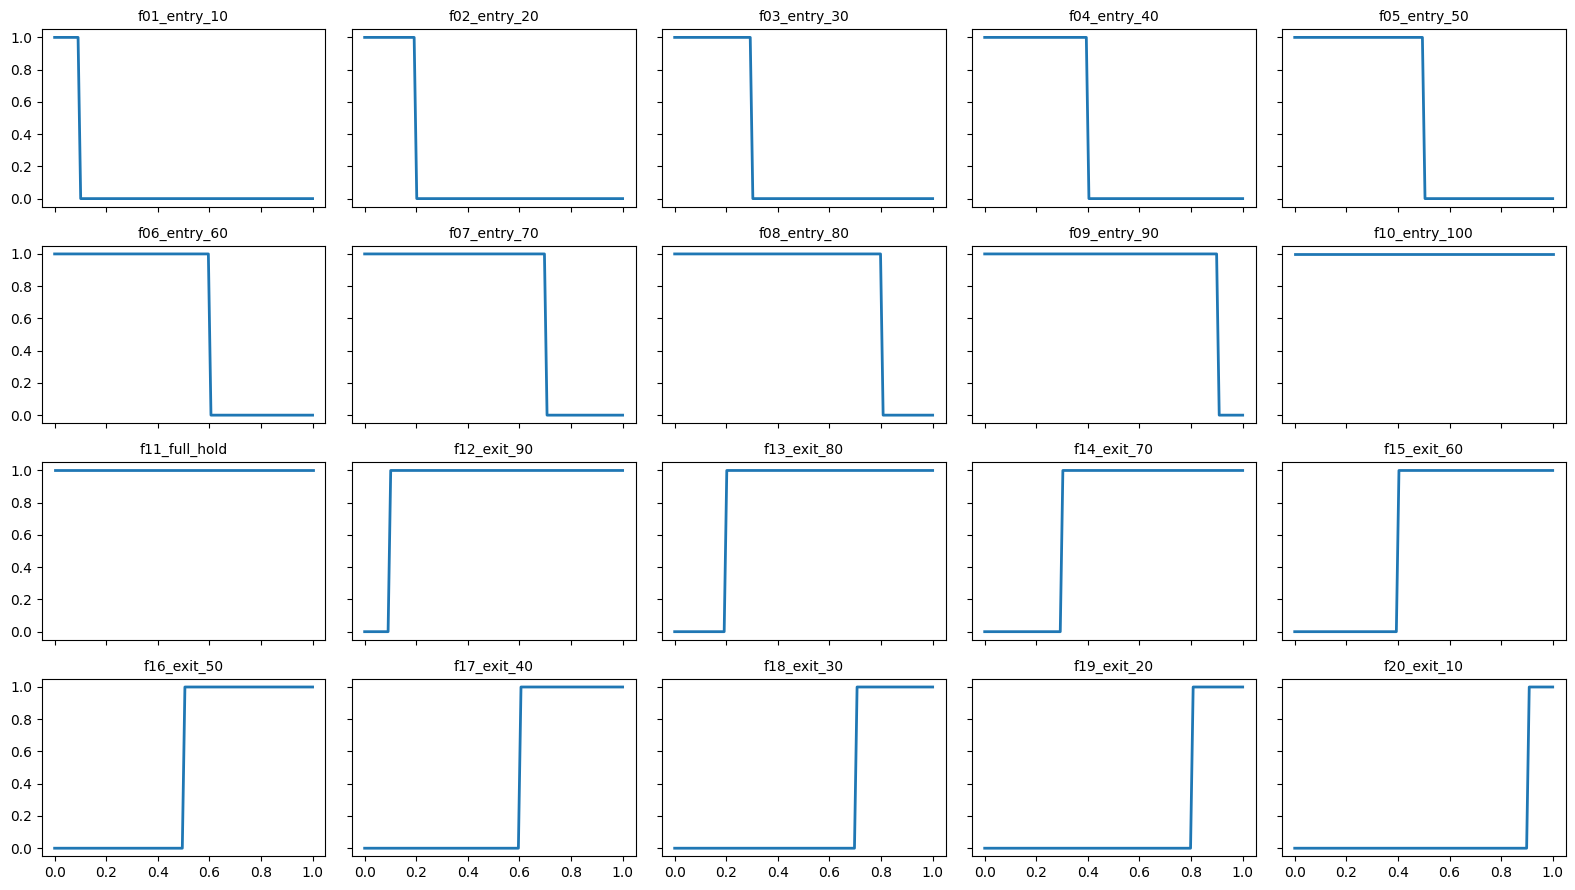

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\20212358\\OneDrive - TU Eindhoven\\pseudotime_GitHUB\\copy_pseudotime_highres_confinement_scan\\datasets\\for Danya ML\\combined_clustered_data_1476_k2.csv'

In [16]:
# gifs for surface 1476
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
import imageio.v2 as imageio

from IPython.display import display, Image as IPyImage
from PIL import Image


# ============================================================
# USER CONFIG — SURFACE 1476
# ============================================================
CSV_PATH = Path(r"C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\copy_pseudotime_highres_confinement_scan\datasets\for Danya ML\combined_clustered_data_1476_k2.csv")
OUT_DIR = Path("1476_frame_candidate_search_output_020426")

BG_COL = "path_background"
DAPI_COL = "path_dapi"

PT_BINS_COL = "pseudotime"
PT_WIDTHS_COL = "pseudotime_widths"
PT_CENTER_COL = "pseudotime_center_bin"

IMAGE_NUM_COL = "dapi_ImageNumber"
OBJECT_NUM_COL = "ObjectNumber"

N_PROFILE = 100
TOP_K_PER_FRAME = 50
ROWS_PER_CONTACT_SHEET = 10

# display settings
BF_WEIGHT = 0.35
DAPI_GAIN = 4.0
DAPI_FIXED_MAX = 160.0
INVERT_BF = True

# crop settings
CROP_THR = 0.15
CROP_PAD = 25

# score weights
W_EMD = 0.50
W_COM = 0.30
W_L2 = 0.20
assert abs((W_EMD + W_COM + W_L2) - 1.0) < 1e-9


# ============================================================
# PARSING + BASIC HELPERS
# ============================================================
def parse_vec(x, dtype=float):
    if isinstance(x, np.ndarray):
        return x.astype(dtype)
    if isinstance(x, list):
        return np.asarray(x, dtype=dtype)
    if pd.isna(x):
        return np.array([], dtype=dtype)

    s = str(x).replace("[", " ").replace("]", " ").replace(",", " ").strip()
    if not s:
        return np.array([], dtype=dtype)

    parts = [p for p in s.split() if p]
    return np.asarray(parts, dtype=dtype)


def build_unique_key(row):
    img_num = row.get(IMAGE_NUM_COL, np.nan)
    obj_num = row.get(OBJECT_NUM_COL, np.nan)

    if pd.notna(img_num) and pd.notna(obj_num):
        return f"img{int(img_num):05d}_obj{int(obj_num):05d}"

    stem = Path(str(row.get(DAPI_COL, "missing_dapi"))).stem
    if pd.notna(obj_num):
        return f"{stem}_obj{int(obj_num):05d}"
    return stem


def resolve_existing_path(path_str):
    p = Path(path_str)
    if p.exists():
        return p

    p2 = Path(p.name)
    if p2.exists():
        return p2

    return p


def read_image(path):
    return tifffile.imread(str(resolve_existing_path(path)))


def to_2d(img):
    img = np.asarray(img)
    if img.ndim == 2:
        return img
    if img.ndim == 3:
        if img.shape[0] == 1:
            return img[0]
        if img.shape[-1] == 1:
            return img[..., 0]
        return img[0] if img.shape[0] <= 4 else img[..., 0]
    raise ValueError(f"Unsupported image shape: {img.shape}")


def normalize_percentile(img, pmin=1, pmax=99):
    img = np.asarray(img, dtype=np.float32)
    lo = np.percentile(img, pmin)
    hi = np.percentile(img, pmax)
    if hi <= lo:
        return np.zeros_like(img, dtype=np.float32)
    return np.clip((img - lo) / (hi - lo), 0, 1)


def scale_dapi_fixed(dapi, fixed_max=160.0):
    dapi = np.asarray(dapi, dtype=np.float32)
    if fixed_max <= 0:
        raise ValueError("fixed_max must be > 0")
    return np.clip(dapi / fixed_max, 0, 1)


def make_overlay_fixed_dapi(
    bg,
    dapi,
    bf_weight=0.35,
    dapi_gain=4.0,
    invert_bf=True,
    dapi_fixed_max=160.0
):
    bg_norm = normalize_percentile(bg, 1, 99)

    if invert_bf:
        bg_norm = 1.0 - bg_norm

    dapi_disp = scale_dapi_fixed(dapi, fixed_max=dapi_fixed_max)
    dapi_enh = np.clip(dapi_disp * dapi_gain, 0, 1)

    rgb = np.zeros((*bg.shape, 3), dtype=np.float32)
    rgb[..., 0] = bg_norm * bf_weight
    rgb[..., 1] = bg_norm * bf_weight
    rgb[..., 2] = bg_norm * bf_weight

    rgb[..., 2] += dapi_enh
    rgb[..., 1] += dapi_enh * 0.15
    rgb[..., 0] += dapi_enh * 0.05
    rgb = np.clip(rgb, 0, 1)

    return rgb, dapi_disp, dapi_enh


def crop_from_signal(img, signal, thr=0.15, pad=25):
    mask = signal > thr
    ys, xs = np.where(mask)

    if len(xs) == 0:
        return img

    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, img.shape[0])
    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, img.shape[1])

    return img[y0:y1, x0:x1]


def linearize_profile(pt_bins, pt_widths, period_len):
    v = np.zeros(period_len, dtype=float)

    pt_bins = np.asarray(pt_bins, dtype=int)
    pt_widths = np.asarray(pt_widths, dtype=float)

    if len(pt_bins) == 0 or len(pt_widths) == 0 or len(pt_bins) != len(pt_widths):
        return v

    for b, w in zip(pt_bins, pt_widths):
        if 0 <= int(b) < period_len:
            v[int(b)] = float(w)

    return v


def centered_profile(linear_profile, center_bin):
    v = np.asarray(linear_profile, dtype=float)
    if len(v) == 0:
        return v

    center_bin = int(center_bin) if pd.notna(center_bin) else 0
    shift = len(v) // 2 - center_bin
    return np.roll(v, shift)


def resample_profile(v, n=100):
    v = np.asarray(v, dtype=float)
    if len(v) == 0:
        return np.zeros(n, dtype=float)
    if len(v) == 1:
        return np.repeat(v[0], n).astype(float)

    x_old = np.linspace(0, 1, len(v))
    x_new = np.linspace(0, 1, n)
    return np.interp(x_new, x_old, v)


def normalize_profile(v):
    v = np.asarray(v, dtype=float)
    v = np.clip(v, 0, None)
    s = v.sum()
    if s <= 0:
        return np.zeros_like(v, dtype=float)
    return v / s


def profile_center_of_mass(v):
    p = normalize_profile(v)
    if p.sum() <= 0:
        return np.nan
    x = np.linspace(0, 1, len(p))
    return float((x * p).sum())


# ============================================================
# FRAME TEMPLATES + SCORING
# ============================================================
def make_20_frame_templates(n=100):
    templates = []

    for i in range(1, 11):
        frac = i / 10.0
        t = np.zeros(n, dtype=float)
        t[:max(1, int(round(frac * n)))] = 1.0
        templates.append({
            "frame_idx": i,
            "frame_name": f"f{i:02d}_entry_{int(frac*100):02d}",
            "frame_kind": "entry",
            "start_frac": 0.0,
            "end_frac": frac,
            "template": t,
        })

    templates.append({
        "frame_idx": 11,
        "frame_name": "f11_full_hold",
        "frame_kind": "hold",
        "start_frac": 0.0,
        "end_frac": 1.0,
        "template": np.ones(n, dtype=float),
    })

    for j, frac in enumerate(np.arange(0.1, 1.0, 0.1), start=12):
        t = np.ones(n, dtype=float)
        t[:int(round(frac * n))] = 0.0
        remain = int(round((1.0 - frac) * 100))

        templates.append({
            "frame_idx": j,
            "frame_name": f"f{j:02d}_exit_{remain:02d}",
            "frame_kind": "exit",
            "start_frac": float(frac),
            "end_frac": 1.0,
            "template": t,
        })

    return templates


FRAME_TEMPLATES = make_20_frame_templates(n=N_PROFILE)


def score_profile_against_template(profile_100, template_100):
    p = normalize_profile(profile_100)
    t = normalize_profile(template_100)

    if p.sum() <= 0 or t.sum() <= 0:
        return np.nan, np.nan, np.nan, np.nan

    cdf_p = np.cumsum(p)
    cdf_t = np.cumsum(t)

    emd_like = float(np.mean(np.abs(cdf_p - cdf_t)))
    com_dist = float(abs(profile_center_of_mass(p) - profile_center_of_mass(t)))
    l2_dist = float(np.linalg.norm(p - t))

    score = W_EMD * emd_like + W_COM * com_dist + W_L2 * l2_dist
    return score, emd_like, com_dist, l2_dist


def plot_frame_templates():
    fig, axes = plt.subplots(4, 5, figsize=(16, 9), sharex=True, sharey=True)
    axes = axes.ravel()

    x = np.linspace(0, 1, N_PROFILE)

    for ax, spec in zip(axes, FRAME_TEMPLATES):
        ax.plot(x, spec["template"], linewidth=2)
        ax.set_title(spec["frame_name"], fontsize=10)
        ax.set_ylim(-0.05, 1.05)

    for ax in axes[len(FRAME_TEMPLATES):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_frame_templates()


# ============================================================
# LOAD METADATA + PREPARE PROFILES
# ============================================================
required_cols = [
    BG_COL,
    DAPI_COL,
    PT_BINS_COL,
    PT_WIDTHS_COL,
    PT_CENTER_COL,
    IMAGE_NUM_COL,
    OBJECT_NUM_COL,
]

tmp_df = pd.read_csv(CSV_PATH, nrows=5)
missing = [c for c in required_cols if c not in tmp_df.columns]
if missing:
    raise ValueError(f"Missing required columns in {CSV_PATH.name}: {missing}")

df = pd.read_csv(CSV_PATH).copy()

df["pt_bins_arr"] = df[PT_BINS_COL].apply(lambda x: parse_vec(x, dtype=int))
df["pt_widths_arr"] = df[PT_WIDTHS_COL].apply(lambda x: parse_vec(x, dtype=float))
df["pt_center_bin_num"] = pd.to_numeric(df[PT_CENTER_COL], errors="coerce")
df["unique_key"] = df.apply(build_unique_key, axis=1)

df["vec_len_match"] = df["pt_bins_arr"].apply(len) == df["pt_widths_arr"].apply(len)

PERIOD_LENGTH = int(df["pt_bins_arr"].apply(lambda a: a.max() if len(a) else -1).max() + 1)

df["linear_profile"] = df.apply(
    lambda r: linearize_profile(r["pt_bins_arr"], r["pt_widths_arr"], PERIOD_LENGTH),
    axis=1,
)
df["centered_profile"] = df.apply(
    lambda r: centered_profile(r["linear_profile"], r["pt_center_bin_num"]),
    axis=1,
)
df["profile_100"] = df["linear_profile"].apply(lambda v: resample_profile(v, n=N_PROFILE))
df["profile_100_norm"] = df["profile_100"].apply(normalize_profile)
df["profile_com"] = df["profile_100_norm"].apply(profile_center_of_mass)

print("Rows:", len(df))
print("Period length:", PERIOD_LENGTH)
print("Vector length matches:", int(df["vec_len_match"].sum()), "/", len(df))
print("Unique objects:", df["unique_key"].nunique())

display(
    df[[
        "unique_key",
        BG_COL,
        DAPI_COL,
        PT_CENTER_COL,
        "vec_len_match",
        "profile_com",
    ]].head()
)


# ============================================================
# SCORE EVERY OBJECT AGAINST EVERY FRAME
# ============================================================
candidate_rows = []

for idx, row in df.iterrows():
    profile_100 = row["profile_100"]

    for spec in FRAME_TEMPLATES:
        score, emd_like, com_dist, l2_dist = score_profile_against_template(
            profile_100,
            spec["template"]
        )

        candidate_rows.append({
            "row_idx": idx,
            "unique_key": row["unique_key"],
            "frame_idx": spec["frame_idx"],
            "frame_name": spec["frame_name"],
            "frame_kind": spec["frame_kind"],
            "start_frac": spec["start_frac"],
            "end_frac": spec["end_frac"],
            "score": score,
            "emd_like": emd_like,
            "com_dist": com_dist,
            "l2_dist": l2_dist,
            "profile_com": row["profile_com"],
            PT_CENTER_COL: row["pt_center_bin_num"],
            BG_COL: row[BG_COL],
            DAPI_COL: row[DAPI_COL],
        })

candidates = pd.DataFrame(candidate_rows)
candidates["rank_within_frame"] = (
    candidates.groupby("frame_name")["score"]
    .rank(method="first", ascending=True)
)

summary_counts = (
    candidates.groupby("frame_name")
    .size()
    .rename("n_candidates_scored")
    .reset_index()
)

summary_best = (
    candidates.sort_values(["frame_name", "score"])
    .groupby("frame_name")
    .head(10)
    .copy()
)

display(summary_counts)
display(summary_best[[
    "frame_name", "rank_within_frame", "unique_key", "score",
    "emd_like", "com_dist", "l2_dist", PT_CENTER_COL
]].head(30))


# ============================================================
# K2 / 1476 COMPATIBILITY DIAGNOSTICS
# ============================================================
frame_diagnostic = (
    candidates.groupby(["frame_idx", "frame_name"])
    .agg(
        best_score=("score", "min"),
        median_score=("score", "median"),
        n_objects=("unique_key", "nunique"),
    )
    .reset_index()
    .sort_values("frame_idx")
)

display(frame_diagnostic)

best_scores = (
    candidates.groupby("frame_idx")["score"]
    .min()
    .reset_index()
    .sort_values("frame_idx")
)

plt.figure(figsize=(8, 4))
plt.plot(best_scores["frame_idx"], best_scores["score"], marker="o")
plt.xlabel("Frame index")
plt.ylabel("Best score in frame")
plt.title("Surface 1476 (k2): best template match per frame")
plt.grid(True)
plt.show()

print("\nINTERPRETATION:")
print("- This pipeline does NOT use the k=2 cluster labels directly.")
print("- It uses pseudotime profile shape, so it should still run for surface 1476.")
print("- If many frames have much worse best_score than others, the 20-frame story is probably too forced for this surface.")


# ============================================================
# VISUAL INSPECTION HELPERS
# ============================================================
def build_candidate_preview(row_idx, frame_name):
    row = df.loc[row_idx]
    spec = next(s for s in FRAME_TEMPLATES if s["frame_name"] == frame_name)

    bg = to_2d(read_image(row[BG_COL]))
    dapi = to_2d(read_image(row[DAPI_COL]))

    if bg.shape != dapi.shape:
        raise ValueError(
            f"Shape mismatch for {row['unique_key']}: background {bg.shape}, dapi {dapi.shape}"
        )

    overlay, dapi_disp, dapi_enh = make_overlay_fixed_dapi(
        bg,
        dapi,
        bf_weight=BF_WEIGHT,
        dapi_gain=DAPI_GAIN,
        invert_bf=INVERT_BF,
        dapi_fixed_max=DAPI_FIXED_MAX
    )

    overlay_crop = crop_from_signal(overlay, dapi_enh, thr=CROP_THR, pad=CROP_PAD)
    dapi_crop = crop_from_signal(dapi_disp, dapi_enh, thr=CROP_THR, pad=CROP_PAD)

    return {
        "row": row,
        "spec": spec,
        "bg": bg,
        "dapi": dapi,
        "overlay": overlay,
        "overlay_crop": overlay_crop,
        "dapi_crop": dapi_crop,
    }


def plot_centered_profile(ax, centered_profile_vec, frame_spec, title=None):
    y = np.asarray(centered_profile_vec, dtype=float)
    x = np.arange(len(y))

    ax.bar(x, y, width=0.9)
    ax.axhline(0, linewidth=1)

    start = int(round(frame_spec["start_frac"] * len(y)))
    end = int(round(frame_spec["end_frac"] * len(y)))
    end = max(start + 1, end)

    ax.axvspan(start, end, alpha=0.15, color="red")
    if title is not None:
        ax.set_title(title, fontsize=10)


def preview_frame_candidates(frame_name, n=6):
    sub = candidates.loc[candidates["frame_name"] == frame_name].sort_values("score").head(n)

    fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(12, 3.2 * n))

    if n == 1:
        axes = np.array([axes])

    for ax_row, (_, cand) in zip(axes, sub.iterrows()):
        row_idx = int(cand["row_idx"])
        pack = build_candidate_preview(row_idx, frame_name)
        row = pack["row"]
        spec = pack["spec"]

        ax_row[0].imshow(pack["overlay_crop"])
        ax_row[0].set_title(f"{row['unique_key']}\nscore={cand['score']:.4f}")
        ax_row[0].axis("off")

        ax_row[1].imshow(pack["dapi_crop"], cmap="gray")
        ax_row[1].set_title("Fixed-scale DAPI crop")
        ax_row[1].axis("off")

        plot_centered_profile(
            ax_row[2],
            row["centered_profile"],
            spec,
            title=f"{frame_name} | center_bin={row['pt_center_bin_num']}"
        )

    plt.tight_layout()
    plt.show()


# Example inspection for 1476:
preview_frame_candidates("f01_entry_10", n=4)
preview_frame_candidates("f10_entry_100", n=4)
preview_frame_candidates("f11_full_hold", n=4)
preview_frame_candidates("f20_exit_10", n=4)


# ============================================================
# EXPORT HELPERS
# ============================================================
def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def export_single_candidate_png(row_idx, frame_name, out_path, score):
    pack = build_candidate_preview(row_idx, frame_name)
    row = pack["row"]
    spec = pack["spec"]

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

    axes[0].imshow(pack["overlay_crop"])
    axes[0].set_title(f"{frame_name}\n{row['unique_key']}\nscore={score:.4f}")
    axes[0].axis("off")

    axes[1].imshow(pack["dapi_crop"], cmap="gray")
    axes[1].set_title("Fixed-scale DAPI crop")
    axes[1].axis("off")

    plot_centered_profile(
        axes[2],
        row["centered_profile"],
        spec,
        title=f"center_bin={row['pt_center_bin_num']}"
    )

    plt.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)


def export_contact_sheet(frame_name, frame_df, out_path, rows_per_page=10):
    n = len(frame_df)
    nrows = min(rows_per_page, n)

    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(12, 3.1 * nrows))
    if nrows == 1:
        axes = np.array([axes])

    for ax_row in axes:
        for ax in ax_row:
            ax.axis("off")

    for r, (_, cand) in enumerate(frame_df.head(rows_per_page).iterrows()):
        row_idx = int(cand["row_idx"])
        pack = build_candidate_preview(row_idx, frame_name)
        row = pack["row"]
        spec = pack["spec"]

        axes[r, 0].imshow(pack["overlay_crop"])
        axes[r, 0].set_title(f"{row['unique_key']} | score={cand['score']:.4f}")
        axes[r, 0].axis("off")

        plot_centered_profile(
            axes[r, 1],
            row["centered_profile"],
            spec,
            title=f"{frame_name} | center_bin={row['pt_center_bin_num']}"
        )

    plt.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)


def export_frame_groups(candidates_df, out_dir, top_k_per_frame=50, rows_per_contact_sheet=10):
    out_dir = ensure_dir(out_dir)

    manifest_all = []
    summary_rows = []

    for spec in FRAME_TEMPLATES:
        frame_name = spec["frame_name"]
        frame_dir = ensure_dir(out_dir / frame_name)

        sub = (
            candidates_df.loc[candidates_df["frame_name"] == frame_name]
            .sort_values("score", ascending=True)
            .copy()
        )

        if top_k_per_frame is not None:
            sub = sub.head(top_k_per_frame).copy()

        exported_rows = []
        export_rank = 0

        for _, cand in sub.iterrows():
            row_idx = int(cand["row_idx"])
            row = df.loc[row_idx]

            try:
                _ = to_2d(read_image(row[BG_COL]))
                _ = to_2d(read_image(row[DAPI_COL]))

                export_rank += 1
                png_name = f"candidate_{export_rank:04d}_{row['unique_key']}.png"
                png_path = frame_dir / png_name

                export_single_candidate_png(
                    row_idx=row_idx,
                    frame_name=frame_name,
                    out_path=png_path,
                    score=float(cand["score"])
                )

                record = {
                    "frame_name": frame_name,
                    "export_rank": export_rank,
                    "row_idx": row_idx,
                    "unique_key": row["unique_key"],
                    BG_COL: row[BG_COL],
                    DAPI_COL: row[DAPI_COL],
                    PT_CENTER_COL: row["pt_center_bin_num"],
                    "score": float(cand["score"]),
                    "emd_like": float(cand["emd_like"]),
                    "com_dist": float(cand["com_dist"]),
                    "l2_dist": float(cand["l2_dist"]),
                    "png_name": png_name,
                    "selected": 0,
                }
                exported_rows.append(record)
                manifest_all.append(record)

            except Exception as e:
                exported_rows.append({
                    "frame_name": frame_name,
                    "export_rank": np.nan,
                    "row_idx": row_idx,
                    "unique_key": row["unique_key"],
                    "score": float(cand["score"]),
                    "error": str(e),
                    "selected": 0,
                })

        frame_manifest = pd.DataFrame(exported_rows)
        frame_manifest.to_csv(frame_dir / "metadata.csv", index=False)

        successful = frame_manifest["png_name"].notna().sum() if "png_name" in frame_manifest.columns else 0

        if successful > 0:
            contact_path = frame_dir / "contact_sheet_001.png"
            ok_rows = frame_manifest.loc[frame_manifest["png_name"].notna()].copy()
            ok_rows = ok_rows.merge(
                sub[["row_idx", "score"]].drop_duplicates(),
                on=["row_idx", "score"],
                how="left"
            )
            export_contact_sheet(frame_name, ok_rows, contact_path, rows_per_page=rows_per_contact_sheet)

        summary_rows.append({
            "frame_name": frame_name,
            "n_scored": int((candidates_df["frame_name"] == frame_name).sum()),
            "n_exported": int(successful),
            "top_k_limit": top_k_per_frame if top_k_per_frame is not None else "all",
        })

    pd.DataFrame(summary_rows).to_csv(out_dir / "summary_counts.csv", index=False)
    pd.DataFrame(manifest_all).to_csv(out_dir / "summary_best_candidates.csv", index=False)

    print(f"Export finished: {out_dir}")


# ============================================================
# RUN EXPORT
# ============================================================
OUT_DIR.mkdir(parents=True, exist_ok=True)

export_frame_groups(
    candidates_df=candidates,
    out_dir=OUT_DIR,
    top_k_per_frame=TOP_K_PER_FRAME,
    rows_per_contact_sheet=ROWS_PER_CONTACT_SHEET
)


# ============================================================
# STABILIZED GIF BUILD
# ============================================================
GIF_DIR = OUT_DIR / "gif_build_stabilized"
GIF_DIR.mkdir(parents=True, exist_ok=True)

GIF_FRAME_SIZE = (980, 360)
GIF_FRAME_DURATION = 0.005
GIF_HOLD_MIDDLE_N = 2
GIF_HOLD_LAST_N = 6

OVERLAY_CROP_HW = (220, 220)
DAPI_CROP_HW = (180, 180)

DAPI_MASK_REL_THRESHOLD = 0.15
SEQUENCE_MODE = "greedy_smooth"   # "greedy" or "greedy_smooth"


def frame_name_to_index(frame_name):
    m = re.match(r"^f(\d+)_", str(frame_name))
    if m:
        return int(m.group(1))
    return 9999


def get_frame_order(frame_templates):
    names = []
    for spec in frame_templates:
        if isinstance(spec, dict):
            names.append(spec["frame_name"])
        else:
            names.append(spec[0])
    return names


def pad_to_canvas(img, out_w, out_h, bg_value=255):
    arr = np.asarray(img)

    if arr.ndim == 2:
        canvas = np.full((out_h, out_w), bg_value, dtype=arr.dtype)
    else:
        canvas = np.full((out_h, out_w, arr.shape[2]), bg_value, dtype=arr.dtype)

    h, w = arr.shape[:2]
    if h == 0 or w == 0:
        return canvas

    scale = min(out_w / w, out_h / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    pil = Image.fromarray(arr)
    pil = pil.resize((new_w, new_h), resample=Image.BILINEAR)
    arr2 = np.asarray(pil)

    y0 = (out_h - new_h) // 2
    x0 = (out_w - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = arr2
    return canvas


def make_binary_mask_from_dapi(dapi_img, rel_thr=DAPI_MASK_REL_THRESHOLD):
    arr = np.asarray(dapi_img).astype(np.float32)
    if arr.size == 0:
        return np.zeros_like(arr, dtype=bool)

    vmax = float(arr.max())
    if vmax <= 0:
        return np.zeros_like(arr, dtype=bool)

    thr = vmax * rel_thr
    return arr > thr


def mask_centroid(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    return float(ys.mean()), float(xs.mean())


def fixed_center_crop(arr, center_y, center_x, crop_h, crop_w, fill_value=0):
    arr = np.asarray(arr)
    H, W = arr.shape[:2]

    y0 = int(round(center_y - crop_h / 2))
    x0 = int(round(center_x - crop_w / 2))
    y1 = y0 + crop_h
    x1 = x0 + crop_w

    src_y0 = max(0, y0)
    src_x0 = max(0, x0)
    src_y1 = min(H, y1)
    src_x1 = min(W, x1)

    dst_y0 = src_y0 - y0
    dst_x0 = src_x0 - x0
    dst_y1 = dst_y0 + (src_y1 - src_y0)
    dst_x1 = dst_x0 + (src_x1 - src_x0)

    if arr.ndim == 2:
        out = np.full((crop_h, crop_w), fill_value, dtype=arr.dtype)
        out[dst_y0:dst_y1, dst_x0:dst_x1] = arr[src_y0:src_y1, src_x0:src_x1]
    else:
        if np.isscalar(fill_value):
            fill = [fill_value] * arr.shape[2]
        else:
            fill = fill_value

        out = np.zeros((crop_h, crop_w, arr.shape[2]), dtype=arr.dtype)
        for c in range(arr.shape[2]):
            out[..., c] = fill[c]
        out[dst_y0:dst_y1, dst_x0:dst_x1] = arr[src_y0:src_y1, src_x0:src_x1]

    return out


def stabilize_candidate_pack(pack, overlay_hw=OVERLAY_CROP_HW, dapi_hw=DAPI_CROP_HW):
    overlay = np.asarray(pack["overlay_crop"])
    dapi = np.asarray(pack["dapi_crop"])

    mask = make_binary_mask_from_dapi(dapi)
    cycx = mask_centroid(mask)

    if cycx is None:
        cy = dapi.shape[0] / 2
        cx = dapi.shape[1] / 2
    else:
        cy, cx = cycx

    overlay_fill = [255, 255, 255] if overlay.ndim == 3 else 255

    overlay_stab = fixed_center_crop(
        overlay,
        cy, cx,
        overlay_hw[0], overlay_hw[1],
        fill_value=overlay_fill
    )

    dapi_stab = fixed_center_crop(
        dapi,
        cy, cx,
        dapi_hw[0], dapi_hw[1],
        fill_value=0
    )

    return {
        **pack,
        "overlay_crop_stab": overlay_stab,
        "dapi_crop_stab": dapi_stab,
        "dapi_mask_stab": make_binary_mask_from_dapi(dapi_stab),
        "stabilized_centroid_yx": (cy, cx),
    }


# ============================================================
# SEQUENCE SELECTION
# ============================================================
FRAME_ORDER = get_frame_order(FRAME_TEMPLATES)


def select_unique_greedy_sequence(candidates_df, frame_order):
    selected_rows = []
    used_keys = set()

    for frame_name in frame_order:
        sub = (
            candidates_df.loc[candidates_df["frame_name"] == frame_name]
            .sort_values(["score", "rank_within_frame"], ascending=[True, True])
            .copy()
        )

        chosen = None
        for _, r in sub.iterrows():
            if r["unique_key"] not in used_keys:
                chosen = r
                break

        if chosen is None:
            print(f"WARNING: no unused candidate found for {frame_name}")
            continue

        selected_rows.append(chosen)
        used_keys.add(chosen["unique_key"])

    seq = pd.DataFrame(selected_rows).reset_index(drop=True)

    if "frame_idx" not in seq.columns:
        seq["frame_idx"] = seq["frame_name"].apply(frame_name_to_index)

    return seq


def estimate_pack_features(pack):
    mask = pack["dapi_mask_stab"]
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return {
            "cx": np.nan,
            "cy": np.nan,
            "area": 0.0,
            "w": 0.0,
            "h": 0.0,
        }

    cx = float(xs.mean())
    cy = float(ys.mean())
    area = float(mask.sum())
    w = float(xs.max() - xs.min() + 1)
    h = float(ys.max() - ys.min() + 1)

    return {
        "cx": cx,
        "cy": cy,
        "area": area,
        "w": w,
        "h": h,
    }


def smooth_cost(prev_feat, curr_feat):
    if prev_feat is None:
        return 0.0

    cx_cost = abs(curr_feat["cx"] - prev_feat["cx"])
    cy_cost = abs(curr_feat["cy"] - prev_feat["cy"])
    area_cost = abs(curr_feat["area"] - prev_feat["area"]) / max(1.0, prev_feat["area"])
    w_cost = abs(curr_feat["w"] - prev_feat["w"]) / max(1.0, prev_feat["w"])
    h_cost = abs(curr_feat["h"] - prev_feat["h"]) / max(1.0, prev_feat["h"])

    return (
        0.8 * cx_cost +
        0.8 * cy_cost +
        20.0 * area_cost +
        8.0 * w_cost +
        8.0 * h_cost
    )


def select_unique_greedy_smooth_sequence(candidates_df, frame_order, top_k_per_frame=12):
    selected_rows = []
    used_keys = set()
    prev_feat = None

    for frame_name in frame_order:
        sub = (
            candidates_df.loc[candidates_df["frame_name"] == frame_name]
            .sort_values(["score", "rank_within_frame"], ascending=[True, True])
            .copy()
            .head(top_k_per_frame)
        )

        best_row = None
        best_total = np.inf
        best_feat = None

        for _, r in sub.iterrows():
            if r["unique_key"] in used_keys:
                continue

            pack = build_candidate_preview(int(r["row_idx"]), r["frame_name"])
            pack = stabilize_candidate_pack(pack)
            feat = estimate_pack_features(pack)

            continuity = smooth_cost(prev_feat, feat)
            total = float(r["score"]) + 0.015 * continuity

            if total < best_total:
                best_total = total
                best_row = r
                best_feat = feat

        if best_row is None:
            print(f"WARNING: no unused candidate found for {frame_name}")
            continue

        selected_rows.append(best_row)
        used_keys.add(best_row["unique_key"])
        prev_feat = best_feat

    seq = pd.DataFrame(selected_rows).reset_index(drop=True)

    if "frame_idx" not in seq.columns:
        seq["frame_idx"] = seq["frame_name"].apply(frame_name_to_index)

    return seq


if SEQUENCE_MODE == "greedy_smooth":
    sequence_auto = select_unique_greedy_smooth_sequence(candidates, FRAME_ORDER, top_k_per_frame=12)
else:
    sequence_auto = select_unique_greedy_sequence(candidates, FRAME_ORDER)

sequence_auto = sequence_auto.sort_values("frame_idx").reset_index(drop=True)

display(sequence_auto[[
    "frame_idx", "frame_name", "unique_key", "score", "pseudotime_center_bin"
]])
print("Frames selected:", len(sequence_auto))
print("Unique objects used:", sequence_auto["unique_key"].nunique())


# ============================================================
# RENDER STABILIZED GIF FRAMES
# ============================================================
def render_sequence_frame(row, out_path=None):
    pack = build_candidate_preview(int(row["row_idx"]), row["frame_name"])
    pack = stabilize_candidate_pack(pack)

    spec = pack["spec"]
    meta_row = pack["row"]

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

    axes[0].imshow(pack["overlay_crop_stab"])
    axes[0].set_title(
        f"{row['frame_name']}\n{meta_row['unique_key']}\nscore={row['score']:.4f}"
    )
    axes[0].axis("off")

    axes[1].imshow(pack["dapi_crop_stab"], cmap="gray")
    axes[1].set_title("Fixed-scale DAPI crop")
    axes[1].axis("off")

    plot_centered_profile(
        axes[2],
        meta_row["centered_profile"],
        spec,
        title=f"center_bin={meta_row['pt_center_bin_num']}"
    )

    plt.tight_layout()

    tmp_path = GIF_DIR / "_tmp_frame.png"
    fig.savefig(tmp_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    arr = imageio.imread(tmp_path)
    arr = pad_to_canvas(arr, GIF_FRAME_SIZE[0], GIF_FRAME_SIZE[1], bg_value=255)

    if out_path is not None:
        imageio.imwrite(out_path, arr)

    return arr


# ============================================================
# BUILD AND SAVE THE MAIN STABILIZED GIF
# ============================================================
gif_frames = []
for _, row in sequence_auto.iterrows():
    out_png = GIF_DIR / f"{int(row['frame_idx']):02d}_{row['frame_name']}.png"
    frame_arr = render_sequence_frame(row, out_path=out_png)
    gif_frames.append(frame_arr)

    if str(row["frame_name"]) in {"f10_entry_100", "f11_full_hold"}:
        for _ in range(GIF_HOLD_MIDDLE_N):
            gif_frames.append(frame_arr)

for _ in range(GIF_HOLD_LAST_N):
    gif_frames.append(gif_frames[-1])

gif_path = GIF_DIR / "animation_auto_stabilized_1476.gif"
imageio.mimsave(gif_path, gif_frames, duration=1.0/GIF_FRAME_DURATION, loop=0)

print("Saved GIF to:", gif_path)
display(IPyImage(filename=str(gif_path)))


# ============================================================
# BUILD 15 STABILIZED GIFS
# GIF 1 uses rank 1 from each frame,
# GIF 2 uses rank 2 from each frame, etc.
# If unique_key repeats within one GIF, skip to next candidate.
# ============================================================
N_GIFS = 15


def build_ranked_sequence(candidates_df, frame_order, rank_start=1):
    selected_rows = []
    used_keys = set()

    for frame_name in frame_order:
        sub = (
            candidates_df.loc[candidates_df["frame_name"] == frame_name]
            .sort_values(["score", "rank_within_frame"], ascending=[True, True])
            .reset_index(drop=True)
            .copy()
        )

        if len(sub) == 0:
            print(f"WARNING: no candidates found for {frame_name}")
            continue

        start_idx = rank_start - 1

        if start_idx >= len(sub):
            print(f"WARNING: frame {frame_name} has fewer than {rank_start} candidates")
            continue

        chosen = None

        for i in range(start_idx, len(sub)):
            r = sub.iloc[i]
            if r["unique_key"] not in used_keys:
                chosen = r
                break

        if chosen is None:
            for i in range(len(sub)):
                r = sub.iloc[i]
                if r["unique_key"] not in used_keys:
                    chosen = r
                    break

        if chosen is None:
            print(f"WARNING: could not find unused candidate for {frame_name}")
            continue

        selected_rows.append(chosen)
        used_keys.add(chosen["unique_key"])

    seq = pd.DataFrame(selected_rows).reset_index(drop=True)

    if len(seq) > 0 and "frame_idx" not in seq.columns:
        seq["frame_idx"] = seq["frame_name"].apply(frame_name_to_index)

    if len(seq) > 0:
        seq = seq.sort_values("frame_idx").reset_index(drop=True)

    return seq


def save_sequence_gif(sequence_df, gif_name, gif_dir=GIF_DIR):
    gif_frames = []

    gif_subdir = gif_dir / gif_name.replace(".gif", "")
    gif_subdir.mkdir(parents=True, exist_ok=True)

    for _, row in sequence_df.iterrows():
        out_png = gif_subdir / f"{int(row['frame_idx']):02d}_{row['frame_name']}.png"
        frame_arr = render_sequence_frame(row, out_path=out_png)
        gif_frames.append(frame_arr)

        if str(row["frame_name"]) in {"f10_entry_100", "f11_full_hold"}:
            for _ in range(GIF_HOLD_MIDDLE_N):
                gif_frames.append(frame_arr)

    if len(gif_frames) == 0:
        print(f"WARNING: no frames generated for {gif_name}")
        return None

    for _ in range(GIF_HOLD_LAST_N):
        gif_frames.append(gif_frames[-1])

    gif_path = gif_dir / gif_name
    imageio.mimsave(gif_path, gif_frames, duration=1.0/GIF_FRAME_DURATION, loop=0)

    print("Saved GIF to:", gif_path)
    return gif_path


gif_paths = []

for gif_rank in range(1, N_GIFS + 1):
    seq = build_ranked_sequence(candidates, FRAME_ORDER, rank_start=gif_rank)

    print(f"\nGIF {gif_rank}: {len(seq)} frames | unique objects = {seq['unique_key'].nunique() if len(seq) else 0}")
    if len(seq) > 0:
        display(seq[["frame_idx", "frame_name", "unique_key", "score"]])

    gif_name = f"animation_auto_stabilized_1476_{gif_rank:02d}.gif"
    gif_path_ranked = save_sequence_gif(seq, gif_name)
    gif_paths.append(gif_path_ranked)

gif_paths

In [16]:
from pathlib import Path
import numpy as np
from PIL import Image, ImageChops
from skimage.registration import phase_cross_correlation

# ============================================================
# PATHS
# ============================================================
folder_1462 = Path(r"C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\GIF\CANDIDATES\1462\FINAL")
folder_1476 = Path(r"C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\GIF\CANDIDATES\1476\FINAL")
out_dir = Path(r"C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\GIF\CANDIDATES\COMPOSITES")
out_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# SETTINGS
# ============================================================
UPSAMPLE = 100
BG = (255, 255, 255)

# Choose a small distinctive topo-only patch for each surface.
# Do NOT include the blue nucleus.
ROI_1462 = (15, 15, 70, 70)   # adjust if needed
ROI_1476 = (15, 15, 70, 70)   # adjust if needed

ROW_GAP = 6
COL_GAP = 10
PANEL_GAP = 18
OUTER_MARGIN = 6

# ============================================================
# FILE HELPERS
# ============================================================
def find_existing_file(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "None of these files exist:\n" + "\n".join(str(p) for p in candidates)
    )

def load_pair(folder, i):
    nuclei_path = find_existing_file([
        folder / f"frame_{i}_nuclei.png",
        folder / f"frame_{i}_nuclei.PNG",
    ])

    pseudo_path = find_existing_file([
        folder / f"frame_{i}_pseudotime_bin.png",
        folder / f"frame_{i}_pseudotime.png",
        folder / f"frame_{i}_pseudotime_bin.PNG",
        folder / f"frame_{i}_pseudotime.PNG",
    ])

    n = Image.open(nuclei_path).convert("RGB")
    p = Image.open(pseudo_path).convert("RGB")
    return n, p

# ============================================================
# IMAGE HELPERS
# ============================================================
def to_gray(img):
    return np.asarray(img.convert("L"), dtype=np.float32)

def trim_plot(img, tolerance=6):
    bg_img = Image.new("RGB", img.size, (255, 255, 255))
    diff = ImageChops.difference(img, bg_img)

    def threshold(v):
        return 255 if v > tolerance else 0

    mask = diff.convert("L").point(threshold)
    bbox = mask.getbbox()
    return img.crop(bbox) if bbox else img

def crop_roi(img, roi):
    x1, y1, x2, y2 = roi
    w, h = img.size
    x1 = max(0, min(x1, w - 1))
    y1 = max(0, min(y1, h - 1))
    x2 = max(x1 + 1, min(x2, w))
    y2 = max(y1 + 1, min(y2, h))
    return img.crop((x1, y1, x2, y2))

def pad_arrays_to_same_shape(a, b):
    H = max(a.shape[0], b.shape[0])
    W = max(a.shape[1], b.shape[1])

    a_pad = np.full((H, W), float(a.mean()), dtype=np.float32)
    b_pad = np.full((H, W), float(b.mean()), dtype=np.float32)

    a_pad[:a.shape[0], :a.shape[1]] = a
    b_pad[:b.shape[0], :b.shape[1]] = b
    return a_pad, b_pad

def compute_shift_roi(ref_img, mov_img, roi):
    """
    Translation that aligns mov_img to ref_img using only the ROI.
    """
    ref_roi = to_gray(crop_roi(ref_img, roi))
    mov_roi = to_gray(crop_roi(mov_img, roi))

    ref_pad, mov_pad = pad_arrays_to_same_shape(ref_roi, mov_roi)
    shift, _, _ = phase_cross_correlation(ref_pad, mov_pad, upsample_factor=UPSAMPLE)

    dy = float(shift[0])
    dx = float(shift[1])
    return dy, dx

def choose_reference_index(images):
    """
    Pick the image with the largest background / field of view.
    Here: largest area first, then width, then height.
    """
    areas = [img.width * img.height for img in images]
    max_area = max(areas)
    candidates = [i for i, a in enumerate(areas) if a == max_area]

    if len(candidates) == 1:
        return candidates[0]

    # tie-breaker: wider image, then taller image
    candidates = sorted(
        candidates,
        key=lambda i: (images[i].width, images[i].height),
        reverse=True
    )
    return candidates[0]

def paste_on_reference_canvas(img, dy, dx, ref_w, ref_h):
    """
    Paste img into the exact reference frame size.
    No resizing, no cropping, translation only.
    """
    canvas = Image.new("RGB", (ref_w, ref_h), BG)

    # Center the raw image in the reference frame first
    base_x = (ref_w - img.width) // 2
    base_y = (ref_h - img.height) // 2

    # Then apply alignment shift
    x = int(round(base_x - dx))
    y = int(round(base_y - dy))

    canvas.paste(img, (x, y))
    return canvas

def pad_to_canvas(img, canvas_w, canvas_h, fill=BG):
    out = Image.new("RGB", (canvas_w, canvas_h), fill)
    x = (canvas_w - img.width) // 2
    y = (canvas_h - img.height) // 2
    out.paste(img, (x, y))
    return out

# ============================================================
# PANEL BUILDER
# ============================================================
def build_panel(folder, roi):
    nuclei = []
    pseudo = []

    for i in range(1, 7):
        n, p = load_pair(folder, i)
        nuclei.append(n)
        pseudo.append(trim_plot(p))

    ref_idx = choose_reference_index(nuclei)
    ref_img = nuclei[ref_idx]
    ref_w, ref_h = ref_img.size

    shifts = []
    aligned_nuclei = []

    for i, img in enumerate(nuclei):
        if i == ref_idx:
            dy, dx = 0.0, 0.0
        else:
            dy, dx = compute_shift_roi(ref_img, img, roi)

        shifts.append((dy, dx))
        aligned = paste_on_reference_canvas(img, dy, dx, ref_w, ref_h)
        aligned_nuclei.append(aligned)

    # Fixed nuclei frame for all 6 rows: exactly the reference size
    nuc_w, nuc_h = ref_w, ref_h

    # Pseudotime plots get a common slot size, but are not resized
    max_pst_w = max(im.width for im in pseudo)
    max_pst_h = max(im.height for im in pseudo)

    row_h = max(nuc_h, max_pst_h)

    panel_w = OUTER_MARGIN + nuc_w + COL_GAP + max_pst_w + OUTER_MARGIN
    panel_h = OUTER_MARGIN + 6 * row_h + 5 * ROW_GAP + OUTER_MARGIN

    panel = Image.new("RGB", (panel_w, panel_h), BG)

    y = OUTER_MARGIN
    for i in range(6):
        nuc_canvas = pad_to_canvas(aligned_nuclei[i], nuc_w, row_h)
        pst_canvas = pad_to_canvas(pseudo[i], max_pst_w, row_h)

        panel.paste(nuc_canvas, (OUTER_MARGIN, y))
        panel.paste(pst_canvas, (OUTER_MARGIN + nuc_w + COL_GAP, y))

        y += row_h + ROW_GAP

    return panel, shifts, ref_idx

def combine_panels(panel_left, panel_right):
    W = OUTER_MARGIN + panel_left.width + PANEL_GAP + panel_right.width + OUTER_MARGIN
    H = OUTER_MARGIN + max(panel_left.height, panel_right.height) + OUTER_MARGIN
    combined = Image.new("RGB", (W, H), BG)

    combined.paste(panel_left, (OUTER_MARGIN, OUTER_MARGIN))
    combined.paste(panel_right, (OUTER_MARGIN + panel_left.width + PANEL_GAP, OUTER_MARGIN))
    return combined

# ============================================================
# RUN
# ============================================================
panel_1462, shifts_1462, ref_idx_1462 = build_panel(folder_1462, ROI_1462)
panel_1476, shifts_1476, ref_idx_1476 = build_panel(folder_1476, ROI_1476)
combined = combine_panels(panel_1462, panel_1476)

panel_1462.save(out_dir / "1462_fixed_reference_frame.png")
panel_1476.save(out_dir / "1476_fixed_reference_frame.png")
combined.save(out_dir / "combined_fixed_reference_frame.png")

print("Saved:")
print(out_dir / "1462_fixed_reference_frame.png")
print(out_dir / "1476_fixed_reference_frame.png")
print(out_dir / "combined_fixed_reference_frame.png")

print("\nReference frame used")
print(f"1462: frame_{ref_idx_1462 + 1}")
print(f"1476: frame_{ref_idx_1476 + 1}")

print("\nShifts relative to reference frame")
print("1462:")
for i, (dy, dx) in enumerate(shifts_1462, start=1):
    print(f"frame_{i}: dy={dy:.3f}, dx={dx:.3f}")

print("\n1476:")
for i, (dy, dx) in enumerate(shifts_1476, start=1):
    print(f"frame_{i}: dy={dy:.3f}, dx={dx:.3f}")

Saved:
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\GIF\CANDIDATES\COMPOSITES\1462_fixed_reference_frame.png
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\GIF\CANDIDATES\COMPOSITES\1476_fixed_reference_frame.png
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\GIF\CANDIDATES\COMPOSITES\combined_fixed_reference_frame.png

Reference frame used
1462: frame_1
1476: frame_6

Shifts relative to reference frame
1462:
frame_1: dy=0.000, dx=0.000
frame_2: dy=-0.190, dx=9.080
frame_3: dy=18.880, dx=18.970
frame_4: dy=0.060, dx=-26.940
frame_5: dy=-22.060, dx=0.970
frame_6: dy=-14.030, dx=5.100

1476:
frame_1: dy=24.940, dx=21.930
frame_2: dy=-22.900, dx=0.130
frame_3: dy=-5.080, dx=3.270
frame_4: dy=18.750, dx=3.010
frame_5: dy=-14.870, dx=3.080
frame_6: dy=0.000, dx=0.000


In [24]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import tifffile
from PIL import Image, ImageChops
from skimage.registration import phase_cross_correlation
from IPython.display import display

# ============================================================
# PROJECT PATHS
# ============================================================
PROJECT_ROOT = Path(r"C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime")

csv_1462 = PROJECT_ROOT / r"datasets\for Danya ML\combined_clustered_data_1462_k5.csv"
csv_1476 = PROJECT_ROOT / r"datasets\for Danya ML\combined_clustered_data_1476_k2.csv"

xlsx_path = PROJECT_ROOT / r"GIF\CANDIDATES\candidate list per surface.xlsx"
out_dir = PROJECT_ROOT / r"GIF\CANDIDATES\COMPOSITES"
out_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# SETTINGS
# ============================================================
sheet_name = 0
UPSAMPLE = 100
BG = (255, 255, 255)

# Registration must use topo/background, not DAPI.
ROI_1462 = (15, 15, 70, 70)
ROI_1476 = (15, 15, 70, 70)

ROW_GAP = 6
COL_GAP = 10
PANEL_GAP = 18
OUTER_MARGIN = 6
PLOT_TRIM_TOL = 6
MIN_CONTENT_GAP = 12

BG_COL = "path_background"
DAPI_COL = "path_dapi"
IMAGE_NUM_COL = "dapi_ImageNumber"
OBJECT_NUM_COL = "ObjectNumber"

FRAME_ORDER_20 = [
    "f01_entry_10",
    "f02_entry_20",
    "f03_entry_30",
    "f04_entry_40",
    "f05_entry_50",
    "f06_entry_60",
    "f07_entry_70",
    "f08_entry_80",
    "f09_entry_90",
    "f10_entry_100",
    "f11_full_hold",
    "f12_exit_90",
    "f13_exit_80",
    "f14_exit_70",
    "f15_exit_60",
    "f16_exit_50",
    "f17_exit_40",
    "f18_exit_30",
    "f19_exit_20",
    "f20_exit_10",
]

# ============================================================
# PATH HELPERS
# ============================================================
def resolve_existing_path(path_like):
    p = Path(str(path_like))
    if p.exists():
        return p

    p2 = Path(p.name)
    if p2.exists():
        return p2

    return p


def normalize_text(x):
    return re.sub(r"[\\/]+", "/", str(x).strip()).lower()


def find_export_root(surface):
    """
    The earlier notebook cells exported to:
      1462_frame_candidate_search_output_020426
      1476_frame_candidate_search_output_020426

    This helper finds the real folder robustly.
    """
    candidates = [
        Path(f"{surface}_frame_candidate_search_output_020426"),
        PROJECT_ROOT / f"{surface}_frame_candidate_search_output_020426",
        PROJECT_ROOT / "GIF" / "CANDIDATES" / surface,
        PROJECT_ROOT / "GIF" / "CANDIDATES" / surface / "FINAL",
    ]

    checked = []
    for c in candidates:
        checked.append(str(c))
        if (c / "summary_best_candidates.csv").exists():
            return c
        if any((c / f).exists() for f in ["summary_counts.csv"]):
            return c
        if list(c.rglob("metadata.csv")):
            return c

    raise FileNotFoundError(
        f"Could not find the export root for surface {surface}.\n"
        f"Checked:\n" + "\n".join(checked)
    )


# ============================================================
# KEY / PARSING HELPERS
# ============================================================
def build_unique_key(row):
    img_num = row.get(IMAGE_NUM_COL, np.nan)
    obj_num = row.get(OBJECT_NUM_COL, np.nan)

    if pd.notna(img_num) and pd.notna(obj_num):
        return f"img{int(img_num):05d}_obj{int(obj_num):05d}"

    stem = Path(str(row.get(DAPI_COL, "missing_dapi"))).stem
    if pd.notna(obj_num):
        return f"{stem}_obj{int(obj_num):05d}"
    return stem


def extract_unique_key(text):
    m = re.search(r"(img\d+_obj\d+)", str(text).lower())
    return m.group(1) if m else None


def extract_candidate_rank(text):
    m = re.search(r"candidate[_\-\s]?(\d+)", str(text).lower())
    return int(m.group(1)) if m else None


def extract_frame_name(text):
    m = re.search(r"(f\d{2}_[a-z0-9_]+)", str(text).lower())
    return m.group(1) if m else None


# ============================================================
# EXCEL LOADING
# ============================================================
def load_selection_table(xlsx_path, sheet_name=0):
    df = pd.read_excel(xlsx_path, sheet_name=sheet_name)
    df.columns = [str(c).strip() for c in df.columns]

    wanted = {"1462", "1476"}
    if wanted.issubset(set(df.columns)):
        return df

    raw = pd.read_excel(xlsx_path, sheet_name=sheet_name, header=None)

    header_row_idx = None
    for i in range(len(raw)):
        vals = [
            str(v).strip()
            for v in raw.iloc[i].tolist()
            if pd.notna(v) and str(v).strip()
        ]
        if "1462" in vals and "1476" in vals:
            header_row_idx = i
            break

    if header_row_idx is None:
        raise KeyError(
            "Could not find columns '1462' and '1476' in the Excel file."
        )

    header = [
        str(v).strip() if pd.notna(v) else ""
        for v in raw.iloc[header_row_idx].tolist()
    ]
    df = raw.iloc[header_row_idx + 1 :].copy()
    df.columns = header
    df = df.loc[:, [c for c in df.columns if str(c).strip() != ""]]
    return df


# ============================================================
# RAW CSV LOOKUP
# ============================================================
def load_raw_lookup(csv_path):
    df = pd.read_csv(csv_path).copy()
    df["unique_key"] = df.apply(build_unique_key, axis=1)
    df["unique_key"] = df["unique_key"].astype(str).str.strip()
    return df


# ============================================================
# MANIFEST LOADING FROM THE FIRST EXPORT
# ============================================================
def load_candidate_manifest(export_root):
    summary_path = export_root / "summary_best_candidates.csv"

    if summary_path.exists():
        manifest = pd.read_csv(summary_path).copy()
    else:
        meta_files = sorted(export_root.rglob("metadata.csv"))
        if not meta_files:
            raise FileNotFoundError(
                f"No summary_best_candidates.csv or metadata.csv found under:\n{export_root}"
            )
        chunks = []
        for p in meta_files:
            tmp = pd.read_csv(p).copy()
            if "frame_name" not in tmp.columns:
                tmp["frame_name"] = p.parent.name
            chunks.append(tmp)
        manifest = pd.concat(chunks, ignore_index=True, sort=False)

    needed = {"frame_name", "unique_key", "png_name", BG_COL, DAPI_COL}
    missing = needed.difference(manifest.columns)
    if missing:
        raise KeyError(
            f"Manifest under {export_root} is missing required columns: {sorted(missing)}"
        )

    manifest["frame_name"] = manifest["frame_name"].astype(str).str.strip()
    manifest["unique_key"] = manifest["unique_key"].astype(str).str.strip()
    manifest["png_name"] = manifest["png_name"].astype(str).str.strip()

    if "export_rank" in manifest.columns:
        manifest["export_rank"] = pd.to_numeric(manifest["export_rank"], errors="coerce")
    else:
        manifest["export_rank"] = np.nan

    manifest["candidate_png_path"] = manifest.apply(
        lambda r: str(export_root / str(r["frame_name"]) / str(r["png_name"])),
        axis=1
    )

    manifest["candidate_png_path_norm"] = manifest["candidate_png_path"].map(normalize_text)
    manifest["png_name_norm"] = manifest["png_name"].map(lambda s: Path(str(s)).name.lower())
    manifest["frame_name_norm"] = manifest["frame_name"].str.lower()
    manifest["unique_key_norm"] = manifest["unique_key"].str.lower()

    return manifest.reset_index(drop=True)


# ============================================================
# MANIFEST MATCHING
# ============================================================
def preview_hits(df_hits, n=8):
    cols = [c for c in ["frame_name", "export_rank", "unique_key", "png_name"] if c in df_hits.columns]
    if len(df_hits) == 0:
        return "<no hits>"
    return df_hits[cols].drop_duplicates().head(n).to_string(index=False)


def resolve_selection_to_manifest(entry, manifest, expected_frame_name=None):
    """
    Matches one Excel entry to exactly one exported candidate row.

    Supports:
    - full path
    - partial path
    - png filename
    - strings containing unique_key
    - strings containing candidate rank
    - strings containing frame name
    """
    s = str(entry).strip()
    s_norm = normalize_text(s)
    base = Path(s).name.lower()
    stem = Path(s).stem.lower()

    unique_key = extract_unique_key(s)
    rank = extract_candidate_rank(s)
    frame_name = extract_frame_name(s) or expected_frame_name

    # 1) exact full-path match
    hits = manifest.loc[manifest["candidate_png_path_norm"] == s_norm].copy()
    if len(hits) == 1:
        return hits.iloc[0]

    # 2) tail-path match
    if "/" in s_norm:
        hits = manifest.loc[
            manifest["candidate_png_path_norm"].str.endswith(s_norm, na=False)
        ].copy()
        if len(hits) == 1:
            return hits.iloc[0]

    # 3) filename + metadata filters
    hits = manifest.copy()

    if base:
        name_hits = hits.loc[hits["png_name_norm"] == base].copy()
        if frame_name is not None:
            name_hits = name_hits.loc[name_hits["frame_name_norm"] == str(frame_name).lower()].copy()
        if unique_key is not None:
            name_hits = name_hits.loc[name_hits["unique_key_norm"] == unique_key.lower()].copy()
        if rank is not None:
            name_hits = name_hits.loc[name_hits["export_rank"] == rank].copy()
        if len(name_hits) == 1:
            return name_hits.iloc[0]
        if len(name_hits) > 1:
            hits = name_hits

    # 4) token filters
    hits = manifest.copy()

    if frame_name is not None:
        hits = hits.loc[hits["frame_name_norm"] == str(frame_name).lower()].copy()

    if unique_key is not None:
        hits = hits.loc[hits["unique_key_norm"] == unique_key.lower()].copy()

    if rank is not None:
        hits = hits.loc[hits["export_rank"] == rank].copy()

    if len(hits) == 1:
        return hits.iloc[0]

    # 5) loose stem match
    if stem:
        loose = manifest.loc[
            manifest["candidate_png_path_norm"].str.contains(re.escape(stem), na=False)
        ].copy()

        if frame_name is not None:
            loose = loose.loc[loose["frame_name_norm"] == str(frame_name).lower()].copy()
        if unique_key is not None:
            loose = loose.loc[loose["unique_key_norm"] == unique_key.lower()].copy()
        if rank is not None:
            loose = loose.loc[loose["export_rank"] == rank].copy()

        if len(loose) == 1:
            return loose.iloc[0]
        if len(loose) > 1:
            hits = loose

    if len(hits) == 0:
        raise KeyError(
            f"Could not resolve Excel entry to the exported candidate manifest:\n{entry}"
        )

    raise ValueError(
        f"Excel entry is ambiguous:\n{entry}\n\n"
        f"Matched {len(hits)} exported candidates.\n"
        f"Top matches:\n{preview_hits(hits)}"
    )


# ============================================================
# RAW ROW RECOVERY
# ============================================================
def resolve_raw_row_from_manifest_row(manifest_row, raw_df):
    key = str(manifest_row["unique_key"]).strip()
    hits = raw_df.loc[raw_df["unique_key"].str.lower() == key.lower()].copy()

    if hits.empty:
        raise KeyError(f"unique_key '{key}' from manifest was not found in raw CSV")

    # Prefer exact background + dapi path match if possible
    bg_path = str(manifest_row.get(BG_COL, "")).strip()
    dapi_path = str(manifest_row.get(DAPI_COL, "")).strip()

    if bg_path:
        exact = hits.loc[hits[BG_COL].astype(str).str.strip() == bg_path].copy()
        if len(exact) == 1:
            exact = exact.reset_index(drop=False).rename(columns={"index": "source_row_index"})
            return exact.iloc[0]

    if dapi_path:
        exact = hits.loc[hits[DAPI_COL].astype(str).str.strip() == dapi_path].copy()
        if len(exact) == 1:
            exact = exact.reset_index(drop=False).rename(columns={"index": "source_row_index"})
            return exact.iloc[0]

    hits = hits.reset_index(drop=False).rename(columns={"index": "source_row_index"})
    return hits.iloc[0]


# ============================================================
# IMAGE HELPERS
# ============================================================
def to_2d(arr):
    arr = np.asarray(arr)
    arr = np.squeeze(arr)

    if arr.ndim == 2:
        return arr

    if arr.ndim == 3:
        if arr.shape[0] <= 4:
            return arr[0]
        if arr.shape[-1] <= 4:
            return arr[..., 0]

    raise ValueError(f"Unsupported image shape: {arr.shape}")


def read_raw_channel(path):
    arr = tifffile.imread(str(resolve_existing_path(path)))
    return to_2d(arr).astype(np.float32)


def normalize_to_uint8(arr, pmin=1, pmax=99.8):
    arr = np.asarray(arr, dtype=np.float32)

    lo = np.percentile(arr, pmin)
    hi = np.percentile(arr, pmax)

    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros(arr.shape, dtype=np.uint8)

    out = np.clip((arr - lo) / (hi - lo), 0, 1)
    return (255 * out).astype(np.uint8)


def read_dapi_as_rgb(path):
    arr = read_raw_channel(path)
    arr8 = normalize_to_uint8(arr)
    return Image.fromarray(arr8, mode="L").convert("RGB")


def trim_plot(img, tolerance=PLOT_TRIM_TOL):
    bg_img = Image.new("RGB", img.size, BG)
    diff = ImageChops.difference(img, bg_img)

    def threshold(v):
        return 255 if v > tolerance else 0

    mask = diff.convert("L").point(threshold)
    bbox = mask.getbbox()
    return img.crop(bbox) if bbox else img


def find_content_column_groups(img, tolerance=PLOT_TRIM_TOL, min_gap=MIN_CONTENT_GAP):
    arr = np.asarray(img.convert("L"))
    non_white = arr < (255 - tolerance)
    cols = np.where(non_white.any(axis=0))[0]

    if len(cols) == 0:
        return []

    groups = []
    start = cols[0]
    prev = cols[0]

    for c in cols[1:]:
        if c - prev > min_gap:
            groups.append((start, prev + 1))
            start = c
        prev = c
    groups.append((start, prev + 1))
    return groups


def extract_pseudotime_panel(candidate_png_path):
    """
    Exported candidate PNG is a 1x3 figure:
      [overlay | dapi crop | centered profile]

    We recover the right-most panel robustly.
    """
    img = Image.open(resolve_existing_path(candidate_png_path)).convert("RGB")
    groups = find_content_column_groups(img)

    if len(groups) >= 3:
        x1, x2 = groups[-1]
        pad = 8
        x1 = max(0, x1 - pad)
        x2 = min(img.width, x2 + pad)
    else:
        x1 = int(round(img.width * 0.62))
        x2 = img.width

    pseudo = img.crop((x1, 0, x2, img.height))
    return trim_plot(pseudo)


def crop_array_roi(arr, roi):
    x1, y1, x2, y2 = roi
    h, w = arr.shape[:2]

    x1 = max(0, min(int(x1), w - 1))
    y1 = max(0, min(int(y1), h - 1))
    x2 = max(x1 + 1, min(int(x2), w))
    y2 = max(y1 + 1, min(int(y2), h))

    return arr[y1:y2, x1:x2]


def pad_arrays(a, b):
    H = max(a.shape[0], b.shape[0])
    W = max(a.shape[1], b.shape[1])

    A = np.full((H, W), float(np.median(a)), dtype=np.float32)
    B = np.full((H, W), float(np.median(b)), dtype=np.float32)

    A[:a.shape[0], :a.shape[1]] = a
    B[:b.shape[0], :b.shape[1]] = b
    return A, B


def prepare_for_registration(arr):
    arr = np.asarray(arr, dtype=np.float32)
    arr = arr - np.median(arr)
    sd = float(arr.std())
    if sd > 0:
        arr = arr / sd
    return arr


def compute_shift_from_background(ref_bg, mov_bg, roi):
    """
    Register using the topo/background channel.
    """
    ref_roi = crop_array_roi(ref_bg, roi)
    mov_roi = crop_array_roi(mov_bg, roi)

    if ref_roi.std() < 1e-6 or mov_roi.std() < 1e-6:
        ref_roi = ref_bg
        mov_roi = mov_bg

    ref_roi, mov_roi = pad_arrays(ref_roi, mov_roi)
    ref_roi = prepare_for_registration(ref_roi)
    mov_roi = prepare_for_registration(mov_roi)

    shift, _, _ = phase_cross_correlation(
        ref_roi,
        mov_roi,
        upsample_factor=UPSAMPLE
    )

    return float(shift[0]), float(shift[1])


def choose_reference_index(bg_arrays):
    areas = [arr.shape[0] * arr.shape[1] for arr in bg_arrays]
    max_area = max(areas)
    candidates = [i for i, a in enumerate(areas) if a == max_area]

    if len(candidates) == 1:
        return candidates[0]

    candidates = sorted(
        candidates,
        key=lambda i: (bg_arrays[i].shape[1], bg_arrays[i].shape[0]),
        reverse=True
    )
    return candidates[0]


def paste_on_reference_canvas(img, dy, dx, ref_w, ref_h):
    canvas = Image.new("RGB", (ref_w, ref_h), BG)

    base_x = (ref_w - img.width) // 2
    base_y = (ref_h - img.height) // 2

    x = int(round(base_x - dx))
    y = int(round(base_y - dy))

    canvas.paste(img, (x, y))
    return canvas


def pad_to_canvas(img, canvas_w, canvas_h, fill=BG):
    out = Image.new("RGB", (canvas_w, canvas_h), fill)
    x = (canvas_w - img.width) // 2
    y = (canvas_h - img.height) // 2
    out.paste(img, (x, y))
    return out


# ============================================================
# EXPECTED FRAME HINTS
# ============================================================
def infer_expected_frames(selection_entries):
    """
    If Excel has exactly 20 rows and does NOT explicitly encode frame names,
    assume it follows the natural 20-frame export order from the first cells.
    Otherwise do not force a frame.
    """
    frames = []
    use_default_order = (
        len(selection_entries) == 20 and
        all(extract_frame_name(x) is None for x in selection_entries)
    )

    for i, entry in enumerate(selection_entries):
        if extract_frame_name(entry) is not None:
            frames.append(extract_frame_name(entry))
        elif use_default_order:
            frames.append(FRAME_ORDER_20[i])
        else:
            frames.append(None)

    return frames


# ============================================================
# PANEL BUILDING
# ============================================================
def build_panel(selection_entries, manifest, raw_df, roi, surface_name):
    expected_frames = infer_expected_frames(selection_entries)

    selected_manifest_rows = []
    selected_raw_rows = []
    bg_arrays = []
    dapi_images = []
    pseudo_plots = []

    for entry, expected_frame in zip(selection_entries, expected_frames):
        hit = resolve_selection_to_manifest(
            entry=entry,
            manifest=manifest,
            expected_frame_name=expected_frame
        )

        raw_row = resolve_raw_row_from_manifest_row(hit, raw_df)

        bg_path = resolve_existing_path(raw_row[BG_COL])
        dapi_path = resolve_existing_path(raw_row[DAPI_COL])
        candidate_png_path = resolve_existing_path(hit["candidate_png_path"])

        if not bg_path.exists():
            raise FileNotFoundError(
                f"Background image does not exist for selection:\n{entry}\n{bg_path}"
            )
        if not dapi_path.exists():
            raise FileNotFoundError(
                f"DAPI image does not exist for selection:\n{entry}\n{dapi_path}"
            )
        if not candidate_png_path.exists():
            raise FileNotFoundError(
                f"Candidate PNG does not exist for selection:\n{entry}\n{candidate_png_path}"
            )

        selected_manifest_rows.append(hit.copy())
        selected_raw_rows.append(raw_row.copy())
        bg_arrays.append(read_raw_channel(bg_path))
        dapi_images.append(read_dapi_as_rgb(dapi_path))
        pseudo_plots.append(extract_pseudotime_panel(candidate_png_path))

    ref_idx = choose_reference_index(bg_arrays)
    ref_bg = bg_arrays[ref_idx]
    ref_w, ref_h = dapi_images[ref_idx].size

    shifts = []
    aligned_dapi = []

    for i, (bg_arr, dapi_img) in enumerate(zip(bg_arrays, dapi_images)):
        if i == ref_idx:
            dy, dx = 0.0, 0.0
        else:
            dy, dx = compute_shift_from_background(ref_bg, bg_arr, roi)

        shifts.append((dy, dx))
        aligned_dapi.append(
            paste_on_reference_canvas(dapi_img, dy, dx, ref_w, ref_h)
        )

    max_pW = max(im.width for im in pseudo_plots)
    max_pH = max(im.height for im in pseudo_plots)
    row_h = max(ref_h, max_pH)

    n_rows = len(selection_entries)
    panel_w = OUTER_MARGIN + ref_w + COL_GAP + max_pW + OUTER_MARGIN
    panel_h = OUTER_MARGIN + n_rows * row_h + max(0, n_rows - 1) * ROW_GAP + OUTER_MARGIN
    panel = Image.new("RGB", (panel_w, panel_h), BG)

    y = OUTER_MARGIN
    for i in range(n_rows):
        nuc_canvas = pad_to_canvas(aligned_dapi[i], ref_w, row_h)
        pst_canvas = pad_to_canvas(pseudo_plots[i], max_pW, row_h)

        panel.paste(nuc_canvas, (OUTER_MARGIN, y))
        panel.paste(pst_canvas, (OUTER_MARGIN + ref_w + COL_GAP, y))
        y += row_h + ROW_GAP

    resolved_df = pd.DataFrame([
        {
            "surface": surface_name,
            "selection_entry": selection_entries[i],
            "expected_frame_hint": expected_frames[i],
            "matched_frame_name": str(selected_manifest_rows[i]["frame_name"]),
            "export_rank": selected_manifest_rows[i].get("export_rank", np.nan),
            "unique_key": str(selected_manifest_rows[i]["unique_key"]),
            "candidate_png_path": str(resolve_existing_path(selected_manifest_rows[i]["candidate_png_path"])),
            "raw_background_path": str(resolve_existing_path(selected_raw_rows[i][BG_COL])),
            "raw_dapi_path": str(resolve_existing_path(selected_raw_rows[i][DAPI_COL])),
            "source_row_index": int(selected_raw_rows[i]["source_row_index"]) if "source_row_index" in selected_raw_rows[i] else np.nan,
            "shift_dy": float(shifts[i][0]),
            "shift_dx": float(shifts[i][1]),
            "used_as_reference": int(i == ref_idx),
        }
        for i in range(len(selection_entries))
    ])

    return panel, ref_idx, shifts, resolved_df


def combine_panels(panel_left, panel_right):
    W = OUTER_MARGIN + panel_left.width + PANEL_GAP + panel_right.width + OUTER_MARGIN
    H = OUTER_MARGIN + max(panel_left.height, panel_right.height) + OUTER_MARGIN
    combined = Image.new("RGB", (W, H), BG)

    combined.paste(panel_left, (OUTER_MARGIN, OUTER_MARGIN))
    combined.paste(panel_right, (OUTER_MARGIN + panel_left.width + PANEL_GAP, OUTER_MARGIN))
    return combined


# ============================================================
# RUN
# ============================================================
export_root_1462 = find_export_root("1462")
export_root_1476 = find_export_root("1476")

print("Resolved export roots:")
print("1462:", export_root_1462)
print("1476:", export_root_1476)

df_excel = load_selection_table(xlsx_path, sheet_name=sheet_name)

names_1462 = [str(v).strip() for v in df_excel["1462"].dropna().tolist() if str(v).strip()]
names_1476 = [str(v).strip() for v in df_excel["1476"].dropna().tolist() if str(v).strip()]

if len(names_1462) == 0:
    raise ValueError("Column 1462 is empty after cleaning.")
if len(names_1476) == 0:
    raise ValueError("Column 1476 is empty after cleaning.")

raw_1462 = load_raw_lookup(csv_1462)
raw_1476 = load_raw_lookup(csv_1476)

manifest_1462 = load_candidate_manifest(export_root_1462)
manifest_1476 = load_candidate_manifest(export_root_1476)

panel_1462, ref_idx_1462, shifts_1462, resolved_1462 = build_panel(
    selection_entries=names_1462,
    manifest=manifest_1462,
    raw_df=raw_1462,
    roi=ROI_1462,
    surface_name="1462",
)

panel_1476, ref_idx_1476, shifts_1476, resolved_1476 = build_panel(
    selection_entries=names_1476,
    manifest=manifest_1476,
    raw_df=raw_1476,
    roi=ROI_1476,
    surface_name="1476",
)

combined = combine_panels(panel_1462, panel_1476)

out_1462 = out_dir / "1462_excel_traceback_aligned_on_background.png"
out_1476 = out_dir / "1476_excel_traceback_aligned_on_background.png"
out_combined = out_dir / "combined_excel_traceback_aligned_on_background.png"
out_resolved_1462 = out_dir / "1462_excel_traceback_aligned_on_background.csv"
out_resolved_1476 = out_dir / "1476_excel_traceback_aligned_on_background.csv"

panel_1462.save(out_1462)
panel_1476.save(out_1476)
combined.save(out_combined)
resolved_1462.to_csv(out_resolved_1462, index=False)
resolved_1476.to_csv(out_resolved_1476, index=False)

print("\nSaved:")
print(out_1462)
print(out_1476)
print(out_combined)
print(out_resolved_1462)
print(out_resolved_1476)

print("\nReference rows used")
print(f"1462 reference row: {ref_idx_1462 + 1}")
print(f"1476 reference row: {ref_idx_1476 + 1}")

print("\nResolved selections for 1462")
display(resolved_1462)

print("\nResolved selections for 1476")
display(resolved_1476)

FileNotFoundError: Could not find the export root for surface 1462.
Checked:
1462_frame_candidate_search_output_020426
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\1462_frame_candidate_search_output_020426
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\GIF\CANDIDATES\1462
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\GIF\CANDIDATES\1462\FINAL

In [34]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import tifffile
from PIL import Image, ImageChops
from skimage.registration import phase_cross_correlation
from IPython.display import display

# ============================================================
# PATHS
# ============================================================
PROJECT_ROOT = Path(r"C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime")
PROJECT_PARENT = PROJECT_ROOT.parent

root_1462 = PROJECT_ROOT / r"GIF\CANDIDATES\1462"
root_1476 = PROJECT_ROOT / r"GIF\CANDIDATES\1476"

csv_1462 = PROJECT_ROOT / r"datasets\combined_clustered_data_1462.csv"
csv_1476 = PROJECT_ROOT / r"datasets\combined_clustered_data_1476.csv"

xlsx_path = PROJECT_ROOT / r"GIF\CANDIDATES\candidate list per surface.xlsx"
out_dir = PROJECT_ROOT / r"GIF\CANDIDATES\COMPOSITES"
out_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# SETTINGS
# ============================================================
sheet_name = 0
UPSAMPLE = 100
BG = (255, 255, 255)

# Alignment must use topo/background, not DAPI
ROI_1462 = (15, 15, 70, 70)
ROI_1476 = (15, 15, 70, 70)

ROW_GAP = 6
COL_GAP = 10
PANEL_GAP = 18
OUTER_MARGIN = 6
PLOT_TRIM_TOL = 6
MIN_CONTENT_GAP = 12

# Overlay settings copied from your export workflow
BF_WEIGHT = 0.35
DAPI_GAIN = 4.0
DAPI_FIXED_MAX = 160.0
INVERT_BF = True

# Crop around aligned signal
CROP_THR = 0.15
CROP_PAD = 25

# ============================================================
# BASIC HELPERS
# ============================================================
def normalize_text(x):
    return re.sub(r"[\\/]+", "/", str(x).strip()).lower()

def normalize_colname(c):
    return re.sub(r"[^a-z0-9]+", "", str(c).strip().lower())

def choose_column(columns, preferred=None, contains_all=None):
    preferred = preferred or []
    contains_all = contains_all or []
    norm = {c: normalize_colname(c) for c in columns}

    for p in preferred:
        p_norm = normalize_colname(p)
        for c, cn in norm.items():
            if cn == p_norm:
                return c

    if contains_all:
        for c, cn in norm.items():
            if all(token in cn for token in contains_all):
                return c

    return None

def resolve_existing_path(path_like):
    p = Path(str(path_like))
    if p.exists():
        return p

    p2 = Path(p.name)
    if p2.exists():
        return p2

    return p

def find_raw_root(surface):
    preferred = PROJECT_PARENT / f"Chip_{surface}_1_real"
    if preferred.exists():
        return preferred

    candidates = []
    seen = set()
    patterns = [
        f"Chip_{surface}_*real*",
        f"Chip_{surface}*real*",
        f"*{surface}*real*",
    ]

    for pattern in patterns:
        for p in PROJECT_PARENT.glob(pattern):
            if p.is_dir():
                rp = p.resolve()
                if str(rp) not in seen:
                    seen.add(str(rp))
                    candidates.append(rp)

    if not candidates:
        raise FileNotFoundError(
            f"Could not find raw root for surface {surface} under:\n{PROJECT_PARENT}"
        )

    candidates = sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

def resolve_path_under_root(path_like, root):
    p = resolve_existing_path(path_like)
    if p.exists():
        return p

    fname = Path(str(path_like)).name
    hits = list(root.rglob(fname))

    if len(hits) == 1:
        return hits[0]

    if len(hits) > 1:
        raise FileNotFoundError(
            f"Multiple files named {fname} found under {root}:\n" +
            "\n".join(str(x) for x in hits[:20])
        )

    raise FileNotFoundError(
        f"Could not resolve file:\n{path_like}\n"
        f"Also could not find {fname} under:\n{root}"
    )

# ============================================================
# EXCEL PARSING
# ============================================================
FRAME_IDX_TO_NAME = {
    1: "f01_entry_10",
    2: "f02_entry_20",
    3: "f03_entry_30",
    4: "f04_entry_40",
    5: "f05_entry_50",
    6: "f06_entry_60",
    7: "f07_entry_70",
    8: "f08_entry_80",
    9: "f09_entry_90",
    10: "f10_entry_100",
    11: "f11_full_hold",
    12: "f12_exit_90",
    13: "f13_exit_80",
    14: "f14_exit_70",
    15: "f15_exit_60",
    16: "f16_exit_50",
    17: "f17_exit_40",
    18: "f18_exit_30",
    19: "f19_exit_20",
    20: "f20_exit_10",
}

def load_selection_table(xlsx_path, sheet_name=0):
    df = pd.read_excel(xlsx_path, sheet_name=sheet_name)
    df.columns = [str(c).strip() for c in df.columns]

    wanted = {"1462", "1476"}
    if wanted.issubset(set(df.columns)):
        return df

    raw = pd.read_excel(xlsx_path, sheet_name=sheet_name, header=None)

    header_row_idx = None
    for i in range(len(raw)):
        vals = [
            str(v).strip()
            for v in raw.iloc[i].tolist()
            if pd.notna(v) and str(v).strip()
        ]
        if "1462" in vals and "1476" in vals:
            header_row_idx = i
            break

    if header_row_idx is None:
        raise KeyError("Could not find columns '1462' and '1476' in the Excel file.")

    header = [
        str(v).strip() if pd.notna(v) else ""
        for v in raw.iloc[header_row_idx].tolist()
    ]
    df = raw.iloc[header_row_idx + 1:].copy()
    df.columns = header
    df = df.loc[:, [c for c in df.columns if str(c).strip() != ""]]
    return df

def extract_unique_key(text):
    m = re.search(r"(img\d+_obj\d+)", str(text).lower())
    return m.group(1) if m else None

def extract_candidate_rank(text):
    m = re.search(r"candidate[_\-\s]?(\d+)", str(text).lower())
    return int(m.group(1)) if m else None

def extract_frame_idx(text):
    m = re.search(r"frame[_\-\s]?(\d+)", str(text).lower())
    return int(m.group(1)) if m else None

def parse_excel_entry(entry):
    s = Path(str(entry).strip()).stem
    unique_key = extract_unique_key(s)
    candidate_rank = extract_candidate_rank(s)
    frame_idx = extract_frame_idx(s)

    if unique_key is None:
        raise ValueError(f"Could not extract unique_key from Excel entry: {entry}")

    frame_name = FRAME_IDX_TO_NAME.get(frame_idx) if frame_idx is not None else None

    return {
        "excel_name": s,
        "unique_key": unique_key,
        "candidate_rank": candidate_rank,
        "frame_idx": frame_idx,
        "frame_name": frame_name,
    }

# ============================================================
# RAW CSV LOOKUP
# ============================================================
def load_raw_lookup(csv_path):
    df = pd.read_csv(csv_path).copy()

    image_col = choose_column(
        df.columns,
        preferred=["dapi_ImageNumber", "ImageNumber", "image_number"],
        contains_all=["image", "number"]
    )
    object_col = choose_column(
        df.columns,
        preferred=["ObjectNumber", "object_number"],
        contains_all=["object", "number"]
    )
    bg_col = choose_column(
        df.columns,
        preferred=["path_background", "background_path"],
        contains_all=["path", "background"]
    )
    dapi_col = choose_column(
        df.columns,
        preferred=["path_dapi", "dapi_path"],
        contains_all=["path", "dapi"]
    )

    needed = [("image_col", image_col), ("object_col", object_col), ("bg_col", bg_col), ("dapi_col", dapi_col)]
    missing = [name for name, col in needed if col is None]
    if missing:
        raise KeyError(
            f"{csv_path.name}: could not detect required columns: {missing}\n"
            f"Columns were:\n" + "\n".join(repr(c) for c in df.columns)
        )

    df["_image_num"] = pd.to_numeric(df[image_col], errors="coerce")
    df["_object_num"] = pd.to_numeric(df[object_col], errors="coerce")
    df["unique_key"] = df.apply(
        lambda r: f"img{int(r[image_col]):05d}_obj{int(r[object_col]):05d}"
        if pd.notna(r[image_col]) and pd.notna(r[object_col]) else "",
        axis=1
    )
    df["unique_key"] = df["unique_key"].astype(str).str.strip()

    return df, {
        "image_col": image_col,
        "object_col": object_col,
        "bg_col": bg_col,
        "dapi_col": dapi_col,
    }

def resolve_excel_entry_to_raw(entry, raw_df):
    info = parse_excel_entry(entry)
    key = info["unique_key"]

    hits = raw_df.loc[raw_df["unique_key"].str.lower() == key.lower()].copy()

    if hits.empty:
        raise KeyError(
            f"unique_key '{key}' from Excel entry '{entry}' was not found in the source CSV"
        )

    hits = hits.reset_index(drop=False).rename(columns={"index": "source_row_index"})
    return hits.iloc[0], info

# ============================================================
# EXPORTED PNG LOOKUP
# ============================================================
def build_png_index(root: Path):
    if not root.exists():
        raise FileNotFoundError(f"Candidate root does not exist:\n{root}")
    return [p for p in root.rglob("*.png") if p.is_file()]

def is_contact_sheet(path: Path):
    return "contact_sheet" in path.name.lower()

def candidate_sort_key(p: Path, frame_name=None, rank=None):
    s = str(p).lower()
    name = p.name.lower()

    frame_match = 0 if (frame_name and frame_name.lower() in s) else 1
    rank_match = 0 if (rank is not None and f"candidate_{rank:04d}" in name) else 1

    final_pref = 0 if "final" in s else 1
    old_penalty = 1 if "old" in s else 0
    intermediate_penalty = 1 if "intermediate" in s else 0

    return (
        frame_match,
        rank_match,
        final_pref,
        old_penalty,
        intermediate_penalty,
        len(p.parts),
        len(str(p)),
    )

def find_candidate_png(entry, info, root, png_files):
    unique_key = info["unique_key"].lower()
    frame_name = info["frame_name"]
    rank = info["candidate_rank"]
    entry_stem = Path(str(entry).strip()).stem.lower()

    usable = [p for p in png_files if not is_contact_sheet(p)]
    key_hits = [p for p in usable if unique_key in p.name.lower()]

    hits = [
        p for p in key_hits
        if (frame_name is None or frame_name.lower() in str(p).lower())
        and (rank is None or f"candidate_{rank:04d}" in p.name.lower())
    ]
    if hits:
        hits = sorted(hits, key=lambda p: candidate_sort_key(p, frame_name, rank))
        return hits[0]

    if frame_name is not None:
        hits = [p for p in key_hits if frame_name.lower() in str(p).lower()]
        if hits:
            hits = sorted(hits, key=lambda p: candidate_sort_key(p, frame_name, rank))
            return hits[0]

    if rank is not None:
        hits = [p for p in key_hits if f"candidate_{rank:04d}" in p.name.lower()]
        if hits:
            hits = sorted(hits, key=lambda p: candidate_sort_key(p, frame_name, rank))
            return hits[0]

    if key_hits:
        key_hits = sorted(key_hits, key=lambda p: candidate_sort_key(p, frame_name, rank))
        return key_hits[0]

    stem_hits = [p for p in usable if entry_stem in p.name.lower()]
    if stem_hits:
        stem_hits = sorted(stem_hits, key=lambda p: candidate_sort_key(p, frame_name, rank))
        return stem_hits[0]

    raise FileNotFoundError(
        f"No exported candidate PNG found under:\n{root}\n"
        f"for Excel entry: {entry}\n"
        f"resolved unique_key: {info['unique_key']}"
    )

# ============================================================
# IMAGE HELPERS
# ============================================================
def to_2d(arr):
    arr = np.asarray(arr)
    arr = np.squeeze(arr)

    if arr.ndim == 2:
        return arr

    if arr.ndim == 3:
        if arr.shape[0] <= 4:
            return arr[0]
        if arr.shape[-1] <= 4:
            return arr[..., 0]

    raise ValueError(f"Unsupported image shape: {arr.shape}")

def read_raw_channel(path):
    arr = tifffile.imread(str(path))
    return to_2d(arr).astype(np.float32)

def normalize_percentile(img, pmin=1, pmax=99):
    img = np.asarray(img, dtype=np.float32)
    lo = np.percentile(img, pmin)
    hi = np.percentile(img, pmax)
    if hi <= lo:
        return np.zeros_like(img, dtype=np.float32)
    return np.clip((img - lo) / (hi - lo), 0, 1)

def scale_dapi_fixed(dapi, fixed_max=160.0):
    dapi = np.asarray(dapi, dtype=np.float32)
    if fixed_max <= 0:
        raise ValueError("fixed_max must be > 0")
    return np.clip(dapi / fixed_max, 0, 1)

def make_overlay_fixed_dapi(
    bg,
    dapi,
    bf_weight=0.35,
    dapi_gain=4.0,
    invert_bf=True,
    dapi_fixed_max=160.0
):
    bg_norm = normalize_percentile(bg, 1, 99)

    if invert_bf:
        bg_norm = 1.0 - bg_norm

    dapi_disp = scale_dapi_fixed(dapi, fixed_max=dapi_fixed_max)
    dapi_enh = np.clip(dapi_disp * dapi_gain, 0, 1)

    rgb = np.zeros((*bg.shape, 3), dtype=np.float32)
    rgb[..., 0] = bg_norm * bf_weight
    rgb[..., 1] = bg_norm * bf_weight
    rgb[..., 2] = bg_norm * bf_weight

    rgb[..., 2] += dapi_enh
    rgb[..., 1] += dapi_enh * 0.15
    rgb[..., 0] += dapi_enh * 0.05
    rgb = np.clip(rgb, 0, 1)

    return rgb, dapi_disp, dapi_enh

def float_rgb_to_pil(rgb):
    rgb8 = np.clip(rgb * 255.0, 0, 255).astype(np.uint8)
    return Image.fromarray(rgb8, mode="RGB")

def trim_plot(img, tolerance=PLOT_TRIM_TOL):
    bg_img = Image.new("RGB", img.size, BG)
    diff = ImageChops.difference(img, bg_img)

    def threshold(v):
        return 255 if v > tolerance else 0

    mask = diff.convert("L").point(threshold)
    bbox = mask.getbbox()
    return img.crop(bbox) if bbox else img

def find_content_column_groups(img, tolerance=PLOT_TRIM_TOL, min_gap=MIN_CONTENT_GAP):
    arr = np.asarray(img.convert("L"))
    non_white = arr < (255 - tolerance)
    cols = np.where(non_white.any(axis=0))[0]

    if len(cols) == 0:
        return []

    groups = []
    start = cols[0]
    prev = cols[0]

    for c in cols[1:]:
        if c - prev > min_gap:
            groups.append((start, prev + 1))
            start = c
        prev = c
    groups.append((start, prev + 1))
    return groups

def extract_pseudotime_panel(candidate_png_path):
    img = Image.open(candidate_png_path).convert("RGB")
    groups = find_content_column_groups(img)

    if len(groups) >= 3:
        x1, x2 = groups[-1]
        pad = 8
        x1 = max(0, x1 - pad)
        x2 = min(img.width, x2 + pad)
    else:
        x1 = int(round(img.width * 2 / 3))
        x2 = img.width

    pseudo = img.crop((x1, 0, x2, img.height))
    return trim_plot(pseudo)

def crop_array_roi(arr, roi):
    x1, y1, x2, y2 = roi
    h, w = arr.shape[:2]

    x1 = max(0, min(int(x1), w - 1))
    y1 = max(0, min(int(y1), h - 1))
    x2 = max(x1 + 1, min(int(x2), w))
    y2 = max(y1 + 1, min(int(y2), h))

    return arr[y1:y2, x1:x2]

def pad_arrays(a, b):
    H = max(a.shape[0], b.shape[0])
    W = max(a.shape[1], b.shape[1])

    A = np.full((H, W), float(np.median(a)), dtype=np.float32)
    B = np.full((H, W), float(np.median(b)), dtype=np.float32)

    A[:a.shape[0], :a.shape[1]] = a
    B[:b.shape[0], :b.shape[1]] = b
    return A, B

def prepare_for_registration(arr):
    arr = np.asarray(arr, dtype=np.float32)
    arr = arr - np.median(arr)
    sd = float(arr.std())
    if sd > 0:
        arr = arr / sd
    return arr

def compute_shift_from_background(ref_bg, mov_bg, roi):
    ref_roi = crop_array_roi(ref_bg, roi)
    mov_roi = crop_array_roi(mov_bg, roi)

    if ref_roi.std() < 1e-6 or mov_roi.std() < 1e-6:
        ref_roi = ref_bg
        mov_roi = mov_bg

    ref_roi, mov_roi = pad_arrays(ref_roi, mov_roi)
    ref_roi = prepare_for_registration(ref_roi)
    mov_roi = prepare_for_registration(mov_roi)

    shift, _, _ = phase_cross_correlation(
        ref_roi,
        mov_roi,
        upsample_factor=UPSAMPLE
    )
    return float(shift[0]), float(shift[1])

def choose_reference_index(bg_arrays):
    areas = [arr.shape[0] * arr.shape[1] for arr in bg_arrays]
    return int(np.argmax(areas))

def paste_image_on_reference_canvas(img, dy, dx, ref_w, ref_h):
    canvas = Image.new("RGB", (ref_w, ref_h), BG)

    base_x = (ref_w - img.width) // 2
    base_y = (ref_h - img.height) // 2

    x = int(round(base_x - dx))
    y = int(round(base_y - dy))

    canvas.paste(img, (x, y))
    return canvas

def paste_array_on_reference_canvas(arr, dy, dx, ref_w, ref_h, fill=0.0):
    arr = np.asarray(arr)
    h, w = arr.shape[:2]

    canvas = np.full((ref_h, ref_w), fill, dtype=arr.dtype)

    base_x = (ref_w - w) // 2
    base_y = (ref_h - h) // 2

    x = int(round(base_x - dx))
    y = int(round(base_y - dy))

    src_x0 = max(0, -x)
    src_y0 = max(0, -y)
    dst_x0 = max(0, x)
    dst_y0 = max(0, y)

    copy_w = min(w - src_x0, ref_w - dst_x0)
    copy_h = min(h - src_y0, ref_h - dst_y0)

    if copy_w > 0 and copy_h > 0:
        canvas[dst_y0:dst_y0 + copy_h, dst_x0:dst_x0 + copy_w] = \
            arr[src_y0:src_y0 + copy_h, src_x0:src_x0 + copy_w]

    return canvas

def signal_bbox(signal, thr=CROP_THR):
    mask = np.asarray(signal) > thr
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    return (int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1)

def bbox_center(bbox, fallback_w, fallback_h):
    if bbox is None:
        return fallback_w // 2, fallback_h // 2
    x0, y0, x1, y1 = bbox
    return int(round((x0 + x1) / 2)), int(round((y0 + y1) / 2))

def crop_pil_with_padding(img, center_x, center_y, crop_w, crop_h, fill=BG):
    W, H = img.size

    x0 = int(round(center_x - crop_w / 2))
    y0 = int(round(center_y - crop_h / 2))
    x1 = x0 + crop_w
    y1 = y0 + crop_h

    out = Image.new("RGB", (crop_w, crop_h), fill)

    src_x0 = max(0, x0)
    src_y0 = max(0, y0)
    src_x1 = min(W, x1)
    src_y1 = min(H, y1)

    if src_x1 > src_x0 and src_y1 > src_y0:
        patch = img.crop((src_x0, src_y0, src_x1, src_y1))
        dst_x = src_x0 - x0
        dst_y = src_y0 - y0
        out.paste(patch, (dst_x, dst_y))

    return out

def pad_to(img, W, H):
    out = Image.new("RGB", (W, H), BG)
    x = (W - img.width) // 2
    y = (H - img.height) // 2
    out.paste(img, (x, y))
    return out

# ============================================================
# PANEL BUILDER
# ============================================================
def build_panel(surface, selection_entries, raw_df, cols, png_files, root, raw_root, roi):
    resolved_rows = []

    bg_arrays = []
    overlay_full_imgs = []
    dapi_signal_arrays = []
    pseudo_imgs = []

    bg_paths = []
    dapi_paths = []
    candidate_png_paths = []

    for entry in selection_entries:
        raw_row, info = resolve_excel_entry_to_raw(entry, raw_df)

        bg_path = resolve_path_under_root(raw_row[cols["bg_col"]], raw_root)
        dapi_path = resolve_path_under_root(raw_row[cols["dapi_col"]], raw_root)

        if not bg_path.exists():
            raise FileNotFoundError(
                f"Resolved raw background path does not exist for entry '{entry}':\n{bg_path}"
            )
        if not dapi_path.exists():
            raise FileNotFoundError(
                f"Resolved raw DAPI path does not exist for entry '{entry}':\n{dapi_path}"
            )

        candidate_png = find_candidate_png(entry, info, root, png_files)

        bg = read_raw_channel(bg_path)
        dapi = read_raw_channel(dapi_path)
        overlay_rgb, _, dapi_enh = make_overlay_fixed_dapi(
            bg,
            dapi,
            bf_weight=BF_WEIGHT,
            dapi_gain=DAPI_GAIN,
            invert_bf=INVERT_BF,
            dapi_fixed_max=DAPI_FIXED_MAX
        )

        bg_arrays.append(bg)
        overlay_full_imgs.append(float_rgb_to_pil(overlay_rgb))
        dapi_signal_arrays.append(dapi_enh)
        pseudo_imgs.append(extract_pseudotime_panel(candidate_png))

        bg_paths.append(bg_path)
        dapi_paths.append(dapi_path)
        candidate_png_paths.append(candidate_png)

        resolved_rows.append({
            "surface": surface,
            "selection_entry": str(entry),
            "source_row_index": int(raw_row["source_row_index"]) if "source_row_index" in raw_row else np.nan,
            "unique_key": str(info["unique_key"]),
            "frame_idx_from_excel": info["frame_idx"],
            "frame_name_from_excel": info["frame_name"],
            "candidate_rank_from_excel": info["candidate_rank"],
        })

    ref_idx = choose_reference_index(bg_arrays)
    ref_bg = bg_arrays[ref_idx]
    ref_h, ref_w = ref_bg.shape[:2]

    shifts = []
    aligned_overlays = []
    aligned_signals = []

    for i, (bg_arr, overlay_img, dapi_sig) in enumerate(zip(bg_arrays, overlay_full_imgs, dapi_signal_arrays)):
        if i == ref_idx:
            dy, dx = 0.0, 0.0
        else:
            dy, dx = compute_shift_from_background(ref_bg, bg_arr, roi)

        shifts.append((dy, dx))
        aligned_overlays.append(
            paste_image_on_reference_canvas(overlay_img, dy, dx, ref_w, ref_h)
        )
        aligned_signals.append(
            paste_array_on_reference_canvas(dapi_sig, dy, dx, ref_w, ref_h, fill=0.0)
        )

    # Fixed crop window based on aligned signal across all selected rows
    bboxes = [signal_bbox(sig, thr=CROP_THR) for sig in aligned_signals]
    valid_bboxes = [b for b in bboxes if b is not None]

    if valid_bboxes:
        max_w = max(b[2] - b[0] for b in valid_bboxes)
        max_h = max(b[3] - b[1] for b in valid_bboxes)
        crop_w = min(ref_w, int(max_w + 2 * CROP_PAD))
        crop_h = min(ref_h, int(max_h + 2 * CROP_PAD))
    else:
        crop_w = min(ref_w, 160)
        crop_h = min(ref_h, 160)

    ref_cx, ref_cy = bbox_center(bboxes[ref_idx], ref_w, ref_h)

    overlay_crops = [
        crop_pil_with_padding(img, ref_cx, ref_cy, crop_w, crop_h, fill=BG)
        for img in aligned_overlays
    ]

    max_pW = max(im.width for im in pseudo_imgs)
    max_pH = max(im.height for im in pseudo_imgs)
    row_h = max(crop_h, max_pH)

    n_rows = len(selection_entries)
    panel_w = OUTER_MARGIN + crop_w + COL_GAP + max_pW + OUTER_MARGIN
    panel_h = OUTER_MARGIN + n_rows * row_h + max(0, n_rows - 1) * ROW_GAP + OUTER_MARGIN
    panel = Image.new("RGB", (panel_w, panel_h), BG)

    y = OUTER_MARGIN
    for i in range(n_rows):
        panel.paste(pad_to(overlay_crops[i], crop_w, row_h), (OUTER_MARGIN, y))
        panel.paste(pad_to(pseudo_imgs[i], max_pW, row_h), (OUTER_MARGIN + crop_w + COL_GAP, y))
        y += row_h + ROW_GAP

    resolved_df = pd.DataFrame([
        {
            **resolved_rows[i],
            "raw_background_path": str(bg_paths[i]),
            "raw_dapi_path": str(dapi_paths[i]),
            "candidate_png_path": str(candidate_png_paths[i]),
            "shift_dy": shifts[i][0],
            "shift_dx": shifts[i][1],
            "used_as_reference": int(i == ref_idx),
        }
        for i in range(len(selection_entries))
    ])

    return panel, ref_idx, shifts, resolved_df

def combine_panels(panel_left, panel_right):
    W = OUTER_MARGIN + panel_left.width + PANEL_GAP + panel_right.width + OUTER_MARGIN
    H = OUTER_MARGIN + max(panel_left.height, panel_right.height) + OUTER_MARGIN
    combined = Image.new("RGB", (W, H), BG)
    combined.paste(panel_left, (OUTER_MARGIN, OUTER_MARGIN))
    combined.paste(panel_right, (OUTER_MARGIN + panel_left.width + PANEL_GAP, OUTER_MARGIN))
    return combined

# ============================================================
# RUN
# ============================================================
df_excel = load_selection_table(xlsx_path, sheet_name=sheet_name)

names_1462 = [str(v).strip() for v in df_excel["1462"].dropna().tolist() if str(v).strip()]
names_1476 = [str(v).strip() for v in df_excel["1476"].dropna().tolist() if str(v).strip()]

if len(names_1462) == 0:
    raise ValueError("Column 1462 is empty after cleaning.")
if len(names_1476) == 0:
    raise ValueError("Column 1476 is empty after cleaning.")

raw_root_1462 = find_raw_root("1462")
raw_root_1476 = find_raw_root("1476")

print("Using raw roots:")
print("1462:", raw_root_1462)
print("1476:", raw_root_1476)

raw_1462, cols_1462 = load_raw_lookup(csv_1462)
raw_1476, cols_1476 = load_raw_lookup(csv_1476)

png_files_1462 = build_png_index(root_1462)
png_files_1476 = build_png_index(root_1476)

panel_1462, ref_idx_1462, shifts_1462, resolved_1462 = build_panel(
    surface="1462",
    selection_entries=names_1462,
    raw_df=raw_1462,
    cols=cols_1462,
    png_files=png_files_1462,
    root=root_1462,
    raw_root=raw_root_1462,
    roi=ROI_1462,
)

panel_1476, ref_idx_1476, shifts_1476, resolved_1476 = build_panel(
    surface="1476",
    selection_entries=names_1476,
    raw_df=raw_1476,
    cols=cols_1476,
    png_files=png_files_1476,
    root=root_1476,
    raw_root=raw_root_1476,
    roi=ROI_1476,
)

combined = combine_panels(panel_1462, panel_1476)

out_1462 = out_dir / "1462_excel_traceback_overlay_aligned_on_background.png"
out_1476 = out_dir / "1476_excel_traceback_overlay_aligned_on_background.png"
out_combined = out_dir / "combined_excel_traceback_overlay_aligned_on_background.png"
out_resolved_1462 = out_dir / "1462_excel_traceback_overlay_aligned_on_background.csv"
out_resolved_1476 = out_dir / "1476_excel_traceback_overlay_aligned_on_background.csv"

panel_1462.save(out_1462)
panel_1476.save(out_1476)
combined.save(out_combined)
resolved_1462.to_csv(out_resolved_1462, index=False)
resolved_1476.to_csv(out_resolved_1476, index=False)

print("\nSaved:")
print(out_1462)
print(out_1476)
print(out_combined)
print(out_resolved_1462)
print(out_resolved_1476)

print("\nReference rows used")
print(f"1462 reference row: {ref_idx_1462 + 1}")
print(f"1476 reference row: {ref_idx_1476 + 1}")

print("\nResolved selections for 1462")
display(resolved_1462)

print("\nResolved selections for 1476")
display(resolved_1476)

Using raw roots:
1462: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\Chip_1462_1_real
1476: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\Chip_1476_1_real


C:\Users\20212358\AppData\Local\Temp\ipykernel_22128\3928625731.py:441: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(rgb8, mode="RGB")
C:\Users\20212358\AppData\Local\Temp\ipykernel_22128\3928625731.py:441: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(rgb8, mode="RGB")
C:\Users\20212358\AppData\Local\Temp\ipykernel_22128\3928625731.py:441: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(rgb8, mode="RGB")
C:\Users\20212358\AppData\Local\Temp\ipykernel_22128\3928625731.py:441: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(rgb8, mode="RGB")
C:\Users\20212358\AppData\Local\Temp\ipykernel_22128\3928625731.py:441: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow


Saved:
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\GIF\CANDIDATES\COMPOSITES\1462_excel_traceback_overlay_aligned_on_background.png
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\GIF\CANDIDATES\COMPOSITES\1476_excel_traceback_overlay_aligned_on_background.png
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\GIF\CANDIDATES\COMPOSITES\combined_excel_traceback_overlay_aligned_on_background.png
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\GIF\CANDIDATES\COMPOSITES\1462_excel_traceback_overlay_aligned_on_background.csv
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\GIF\CANDIDATES\COMPOSITES\1476_excel_traceback_overlay_aligned_on_background.csv

Reference rows used
1462 reference row: 1
1476 reference row: 1

Resolved selections for 1462


,surface,selection_entry,source_row_index,unique_key,frame_idx_from_excel,frame_name_from_excel,candidate_rank_from_excel,raw_background_path,raw_dapi_path,candidate_png_path,shift_dy,shift_dx,used_as_reference
0,1462,frame_1_candidate_0007_img00216_obj00001,215,img00216_obj00001,1,f01_entry_10,7,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,0.0,0.0,1
1,1462,frame_2_candidate_0027_img00307_obj00001,311,img00307_obj00001,2,f02_entry_20,27,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,0.0,0.0,0
2,1462,frame_3_candidate_0002_img00002_obj00001,1,img00002_obj00001,3,f03_entry_30,2,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,0.0,0.0,0
3,1462,frame_4_candidate_0004_img00331_obj00002,335,img00331_obj00002,4,f04_entry_40,4,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,0.0,0.0,0
4,1462,frame_5_candidate_0049_img00035_obj00001,38,img00035_obj00001,5,f05_entry_50,49,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,0.0,0.0,0
5,1462,frame_6_candidate_0037_img00167_obj00002,166,img00167_obj00002,6,f06_entry_60,37,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,0.0,0.0,0



Resolved selections for 1476


,surface,selection_entry,source_row_index,unique_key,frame_idx_from_excel,frame_name_from_excel,candidate_rank_from_excel,raw_background_path,raw_dapi_path,candidate_png_path,shift_dy,shift_dx,used_as_reference
0,1476,frame_1_candidate_0033_img00659_obj00001,605,img00659_obj00001,1,f01_entry_10,33,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,0.0,0.0,1
1,1476,frame_2_candidate_0006_img00722_obj00001,665,img00722_obj00001,2,f02_entry_20,6,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,0.0,0.0,0
2,1476,frame_3_candidate_0006_img00113_obj00001,109,img00113_obj00001,3,f03_entry_30,6,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,0.0,0.0,0
3,1476,frame_4_candidate_0033_img00173_obj00001,164,img00173_obj00001,4,f04_entry_40,33,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,0.0,0.0,0
4,1476,frame_5_candidate_0041_img00284_obj00001,269,img00284_obj00001,5,f05_entry_50,41,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,0.0,0.0,0
5,1476,frame_6_candidate_0047_img00273_obj00001,258,img00273_obj00001,6,f06_entry_60,47,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,0.0,0.0,0
